In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [10]:
data=pd.read_csv("Healthcare Ransomware Dataset.csv")
data.head()

,id,attack_date,org_type,org_size,facilities_affected,cyber_threats_tracked,monitoring_freq,backup_compromised,ransomware_infection_rate_(%),data_encrypted,data_stolen,recovery_time_(days),entry_method,paid_ransom,data_restored,ransomware_incidents
0,RAN202400001,28-06-2024 00:00,Hospital,Large,23,Jan-50,Daily,True,63.30,True,False,64,Exploited Vulnerability,False,36.28,2
1,RAN202400002,18-12-2024 03:00,Pharma,Medium,4,50-350,Daily,False,59.05,True,True,28,Exploited Vulnerability,True,57.66,6
2,RAN202400003,12-10-2024 09:00,Research Lab,Small,18,350+,Daily,True,90.00,True,False,49,Phishing Email,True,61.85,5
3,RAN202400004,28-07-2024 19:00,Clinic,Small,5,Jan-50,Weekly,True,61.32,False,False,56,Compromised Credentials,False,52.44,5
4,RAN202400005,27-06-2024 18:00,Hospital,Large,16,350+,Daily,False,53.65,True,True,13,Exploited Vulnerability,True,75.61,2


In [4]:
data.shape

(5000, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             5000 non-null   object 
 1   attack_date                    5000 non-null   object 
 2   org_type                       5000 non-null   object 
 3   org_size                       5000 non-null   object 
 4   facilities_affected            5000 non-null   int64  
 5   cyber_threats_tracked          5000 non-null   object 
 6   monitoring_freq                5000 non-null   object 
 7   backup_compromised             5000 non-null   bool   
 8   ransomware_infection_rate_(%)  5000 non-null   float64
 9   data_encrypted                 5000 non-null   bool   
 10  data_stolen                    5000 non-null   bool   
 11  recovery_time_(days)           5000 non-null   int64  
 12  entry_method                   5000 non-null   o

In [11]:
# Data Cleaning & Preprocessing
# Drop column id as it's not needed
df=data.drop('id',axis=1)
df.head(10)

,attack_date,org_type,org_size,facilities_affected,cyber_threats_tracked,monitoring_freq,backup_compromised,ransomware_infection_rate_(%),data_encrypted,data_stolen,recovery_time_(days),entry_method,paid_ransom,data_restored,ransomware_incidents
0,28-06-2024 00:00,Hospital,Large,23,Jan-50,Daily,True,63.30,True,False,64,Exploited Vulnerability,False,36.28,2
1,18-12-2024 03:00,Pharma,Medium,4,50-350,Daily,False,59.05,True,True,28,Exploited Vulnerability,True,57.66,6
2,12-10-2024 09:00,Research Lab,Small,18,350+,Daily,True,90.00,True,False,49,Phishing Email,True,61.85,5
3,28-07-2024 19:00,Clinic,Small,5,Jan-50,Weekly,True,61.32,False,False,56,Compromised Credentials,False,52.44,5
4,27-06-2024 18:00,Hospital,Large,16,350+,Daily,False,53.65,True,True,13,Exploited Vulnerability,True,75.61,2
5,25-04-2024 20:00,Hospital,Large,14,Jan-50,More than once per day,False,34.93,True,False,15,Compromised Credentials,False,54.04,3
6,01-12-2024 22:00,Hospital,Medium,19,50-350,Daily,True,57.07,True,False,39,Exploited Vulnerability,True,62.56,3
7,18-04-2024 02:00,Insurance,Large,14,350+,Daily,False,48.08,False,True,16,Exploited Vulnerability,True,75.96,5
8,17-04-2024 17:00,Clinic,Small,9,Jan-50,Monthly,False,47.36,True,False,45,Exploited Vulnerability,False,22.56,1
9,02-08-2024 18:00,Research Lab,Medium,6,50-350,Weekly,True,75.27,True,False,47,Phishing Email,True,45.12,6


In [15]:
df.columns.to_list()

['attack_date',
 'org_type',
 'org_size',
 'facilities_affected',
 'cyber_threats_tracked',
 'monitoring_freq',
 'backup_compromised',
 'ransomware_infection_rate_(%)',
 'data_encrypted',
 'data_stolen',
 'recovery_time_(days)',
 'entry_method',
 'paid_ransom',
 'data_restored',
 'ransomware_incidents']

In [12]:
# column names can be changed for better readability
df.columns=['Attack date',
 'Org type',
 'Org size',
 'Facilities affected',
 'Cyber threats tracked',
 'Monitoring freq',
 'Backup compromised',
 'Ransomware infection rate(%)',
 'Data encrypted',
 'Data stolen',
 'Recovery time(days)',
 'Entry method',
 'Paid ransom',
 'Data restored(%)',
 'Ransomware incidents']
df.columns.tolist()

['Attack date',
 'Org type',
 'Org size',
 'Facilities affected',
 'Cyber threats tracked',
 'Monitoring freq',
 'Backup compromised',
 'Ransomware infection rate(%)',
 'Data encrypted',
 'Data stolen',
 'Recovery time(days)',
 'Entry method',
 'Paid ransom',
 'Data restored(%)',
 'Ransomware incidents']

In [18]:
# Column attack_date has dtype=object, convert to datetime 
df['Attack date'] = pd.to_datetime(df['Attack date']) 

# Extract date
df['Date'] = df['Attack date'].dt.date

# Extract time (hour of the day) & weekday
df['Hour'] = df['Attack date'].dt.hour
df['Weekday'] = df['Attack date'].dt.day_name()
df['Month'] = df['Attack date'].dt.month_name()
df['Day'] = df['Attack date'].dt.day
df.head()

,Attack date,Org type,Org size,Facilities affected,Cyber threats tracked,Monitoring freq,Backup compromised,Ransomware infection rate(%),Data encrypted,Data stolen,...,Entry method,Paid ransom,Data restored(%),Ransomware incidents,Date,Hour,Weekday,Month,Time of Day,Day
0,2024-06-28 00:00:00,Hospital,Large,23,Jan-50,Daily,True,63.30,True,False,...,Exploited Vulnerability,False,36.28,2,2024-06-28,0,Friday,June,Midnight,28
1,2024-12-18 03:00:00,Pharma,Medium,4,50-350,Daily,False,59.05,True,True,...,Exploited Vulnerability,True,57.66,6,2024-12-18,3,Wednesday,December,Midnight,18
2,2024-10-12 09:00:00,Research Lab,Small,18,350+,Daily,True,90.00,True,False,...,Phishing Email,True,61.85,5,2024-10-12,9,Saturday,October,Morning,12
3,2024-07-28 19:00:00,Clinic,Small,5,Jan-50,Weekly,True,61.32,False,False,...,Compromised Credentials,False,52.44,5,2024-07-28,19,Sunday,July,Evening,28
4,2024-06-27 18:00:00,Hospital,Large,16,350+,Daily,False,53.65,True,True,...,Exploited Vulnerability,True,75.61,2,2024-06-27,18,Thursday,June,Evening,27


In [18]:
df['Hour'].value_counts()

Hour
15    240
19    222
9     222
3     218
5     218
21    217
6     216
4     215
2     213
1     213
14    212
10    211
16    210
11    205
23    203
22    202
12    202
8     201
18    197
7     197
0     194
13    193
20    190
17    189
Name: count, dtype: int64

In [14]:
# Codes used for week numbers and time of the day
# Hour can be segregated into morning, midnight, evening, etc.

def Time_of_Day(i):
    if 0 <= i <= 3:
        return 'Midnight'
    elif 4 <= i <= 6:
        return 'Early_Morning'
    elif 7 <= i <= 11:
        return 'Morning'
    elif 12 <= i <= 16:
        return 'Afternoon'
    elif 17 <= i <= 20:
        return 'Evening'
    else:
        return 'Night'

df['Time of Day'] = df['Hour'].apply(Time_of_Day)
df['Time of Day'].value_counts()

Time of Day
Afternoon        1057
Morning          1036
Midnight          838
Evening           798
Early_Morning     649
Night             622
Name: count, dtype: int64

In [15]:
df.columns

Index(['Attack date', 'Org type', 'Org size', 'Facilities affected',
       'Cyber threats tracked', 'Monitoring freq', 'Backup compromised',
       'Ransomware infection rate(%)', 'Data encrypted', 'Data stolen',
       'Recovery time(days)', 'Entry method', 'Paid ransom',
       'Data restored(%)', 'Ransomware incidents', 'Date', 'Hour', 'Weekday',
       'Month', 'Time of Day'],
      dtype='object')

In [20]:
# Day can be segregated into week1, week2.....week4
def Day_to_week(i):
    if 1 <= i <= 7:
        return 'Week 1'
    elif 8 <= i <= 14:
        return 'Week 2'
    elif 15 <= i <= 21:
        return 'Week 3'
    else:
        return 'Week 4'

df['Week num'] = df['Day'].apply(Day_to_week)
df['Week num'].value_counts()

Week num
Week 4    1517
Week 3    1174
Week 1    1155
Week 2    1154
Name: count, dtype: int64

In [21]:
# columns Org size and Org type can be concatenated in another column:
df['Type of organization'] = df['Org size'] + ' ' + df['Org type']
df['Type of organization'].value_counts()

Type of organization
Medium Hospital        1212
Large Hospital          821
Medium Clinic           751
Small Clinic            746
Medium Insurance        324
Medium Pharma           285
Small Research Lab      244
Medium Research Lab     227
Large Insurance         196
Large Pharma            194
Name: count, dtype: int64

In [22]:
# column 'cyber_threats_tracked' needs to be cleaned as Jan-50 should be 1-50.
# column 'monitoring_freq' can be cleaned for better readability, aka converting 'More than once per day' to 'Multiple times daily'
df['Cyber threats tracked'].replace('Jan-50','1-50',inplace=True)
df['Monitoring freq'].replace('More than once per day','Multiple times daily',inplace=True)
print(df['Cyber threats tracked'].unique())
print(df['Monitoring freq'].unique())

['1-50' '50-350' '350+']
['Daily' 'Weekly' 'Multiple times daily' 'Monthly']


In [23]:
df['Date'] = pd.to_datetime(df['Date'])      # convert to datetime
df['Day'] = df['Date'].dt.day  

In [55]:
df.columns.to_list()

['Attack date',
 'Org type',
 'Org size',
 'Facilities affected',
 'Cyber threats tracked',
 'Monitoring freq',
 'Backup compromised',
 'Ransomware infection rate(%)',
 'Data encrypted',
 'Data stolen',
 'Recovery time(days)',
 'Entry method',
 'Paid ransom',
 'Data restored(%)',
 'Ransomware incidents',
 'Date',
 'Hour',
 'Weekday',
 'Time of Day',
 'Type of organization',
 'Month']

In [24]:
# descriptive stats for numeric data
round(df.describe(include=['number']),2)

,Facilities affected,Ransomware infection rate(%),Recovery time(days),Data restored(%),Ransomware incidents,Hour,Day
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,12.76,56.31,43.76,42.76,4.02,11.44,15.66
std,6.94,14.72,21.50,16.95,1.99,6.90,8.77
min,1.00,11.20,2.00,0.00,1.00,0.00,1.00
25%,7.00,47.21,27.00,29.43,2.00,5.00,8.00
50%,13.00,56.73,41.00,43.00,4.00,11.00,16.00
75%,19.00,66.12,58.00,55.57,6.00,17.00,23.00
max,24.00,90.00,120.00,91.13,7.00,23.00,31.00


In [90]:
df.dtypes

Attack date                     datetime64[ns]
Org type                                object
Org size                                object
Facilities affected                      int64
Cyber threats tracked                   object
Monitoring freq                         object
Backup compromised                        bool
Ransomware infection rate(%)           float64
Data encrypted                            bool
Data stolen                               bool
Recovery time(days)                      int64
Entry method                            object
Paid ransom                               bool
Data restored(%)                       float64
Ransomware incidents                     int64
Date                                    object
Hour                                     int32
Weekday                                 object
Month                                   object
Time of Day                             object
Type of organization                    object
dtype: object

In [25]:
# descriptive stats for categorical data
round(df.describe(include=['object']),2)

,Org type,Org size,Cyber threats tracked,Monitoring freq,Entry method,Weekday,Month,Time of Day,Week num,Type of organization
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5,3,3,4,6,7,12,6,4,10
top,Hospital,Medium,1-50,Daily,Compromised Credentials,Monday,August,Afternoon,Week 4,Medium Hospital
freq,2033,2799,2025,1998,1769,741,462,1057,1517,1212


In [26]:
# descriptive stats for boolean data
round(df.describe(include=['bool']),2)

,Backup compromised,Data encrypted,Data stolen,Paid ransom
count,5000,5000,5000,5000
unique,2,2,2,2
top,True,True,False,False
freq,3203,4241,3852,2532


In [93]:
df.columns

Index(['Attack date', 'Org type', 'Org size', 'Facilities affected',
       'Cyber threats tracked', 'Monitoring freq', 'Backup compromised',
       'Ransomware infection rate(%)', 'Data encrypted', 'Data stolen',
       'Recovery time(days)', 'Entry method', 'Paid ransom',
       'Data restored(%)', 'Ransomware incidents', 'Date', 'Hour', 'Weekday',
       'Month', 'Time of Day', 'Type of organization'],
      dtype='object')

In [27]:
# End of Pre-processing
# Lets' start with EDA!....first I will order time-related categories and discrete numeric variables so they show in ordered manner on plots
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

weekday_order = [
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]

time_of_day_order = [
    'Midnight','Early_Morning','Morning','Afternoon','Evening','Night'
]

incident_order = [1,2,3,4,5,6,7]   # for ransomware incidents

In [28]:
orders={
    "Month": month_order,
    "Weekday": weekday_order,
    "Time of Day": time_of_day_order,
    "Ransomware incidents": incident_order,
}

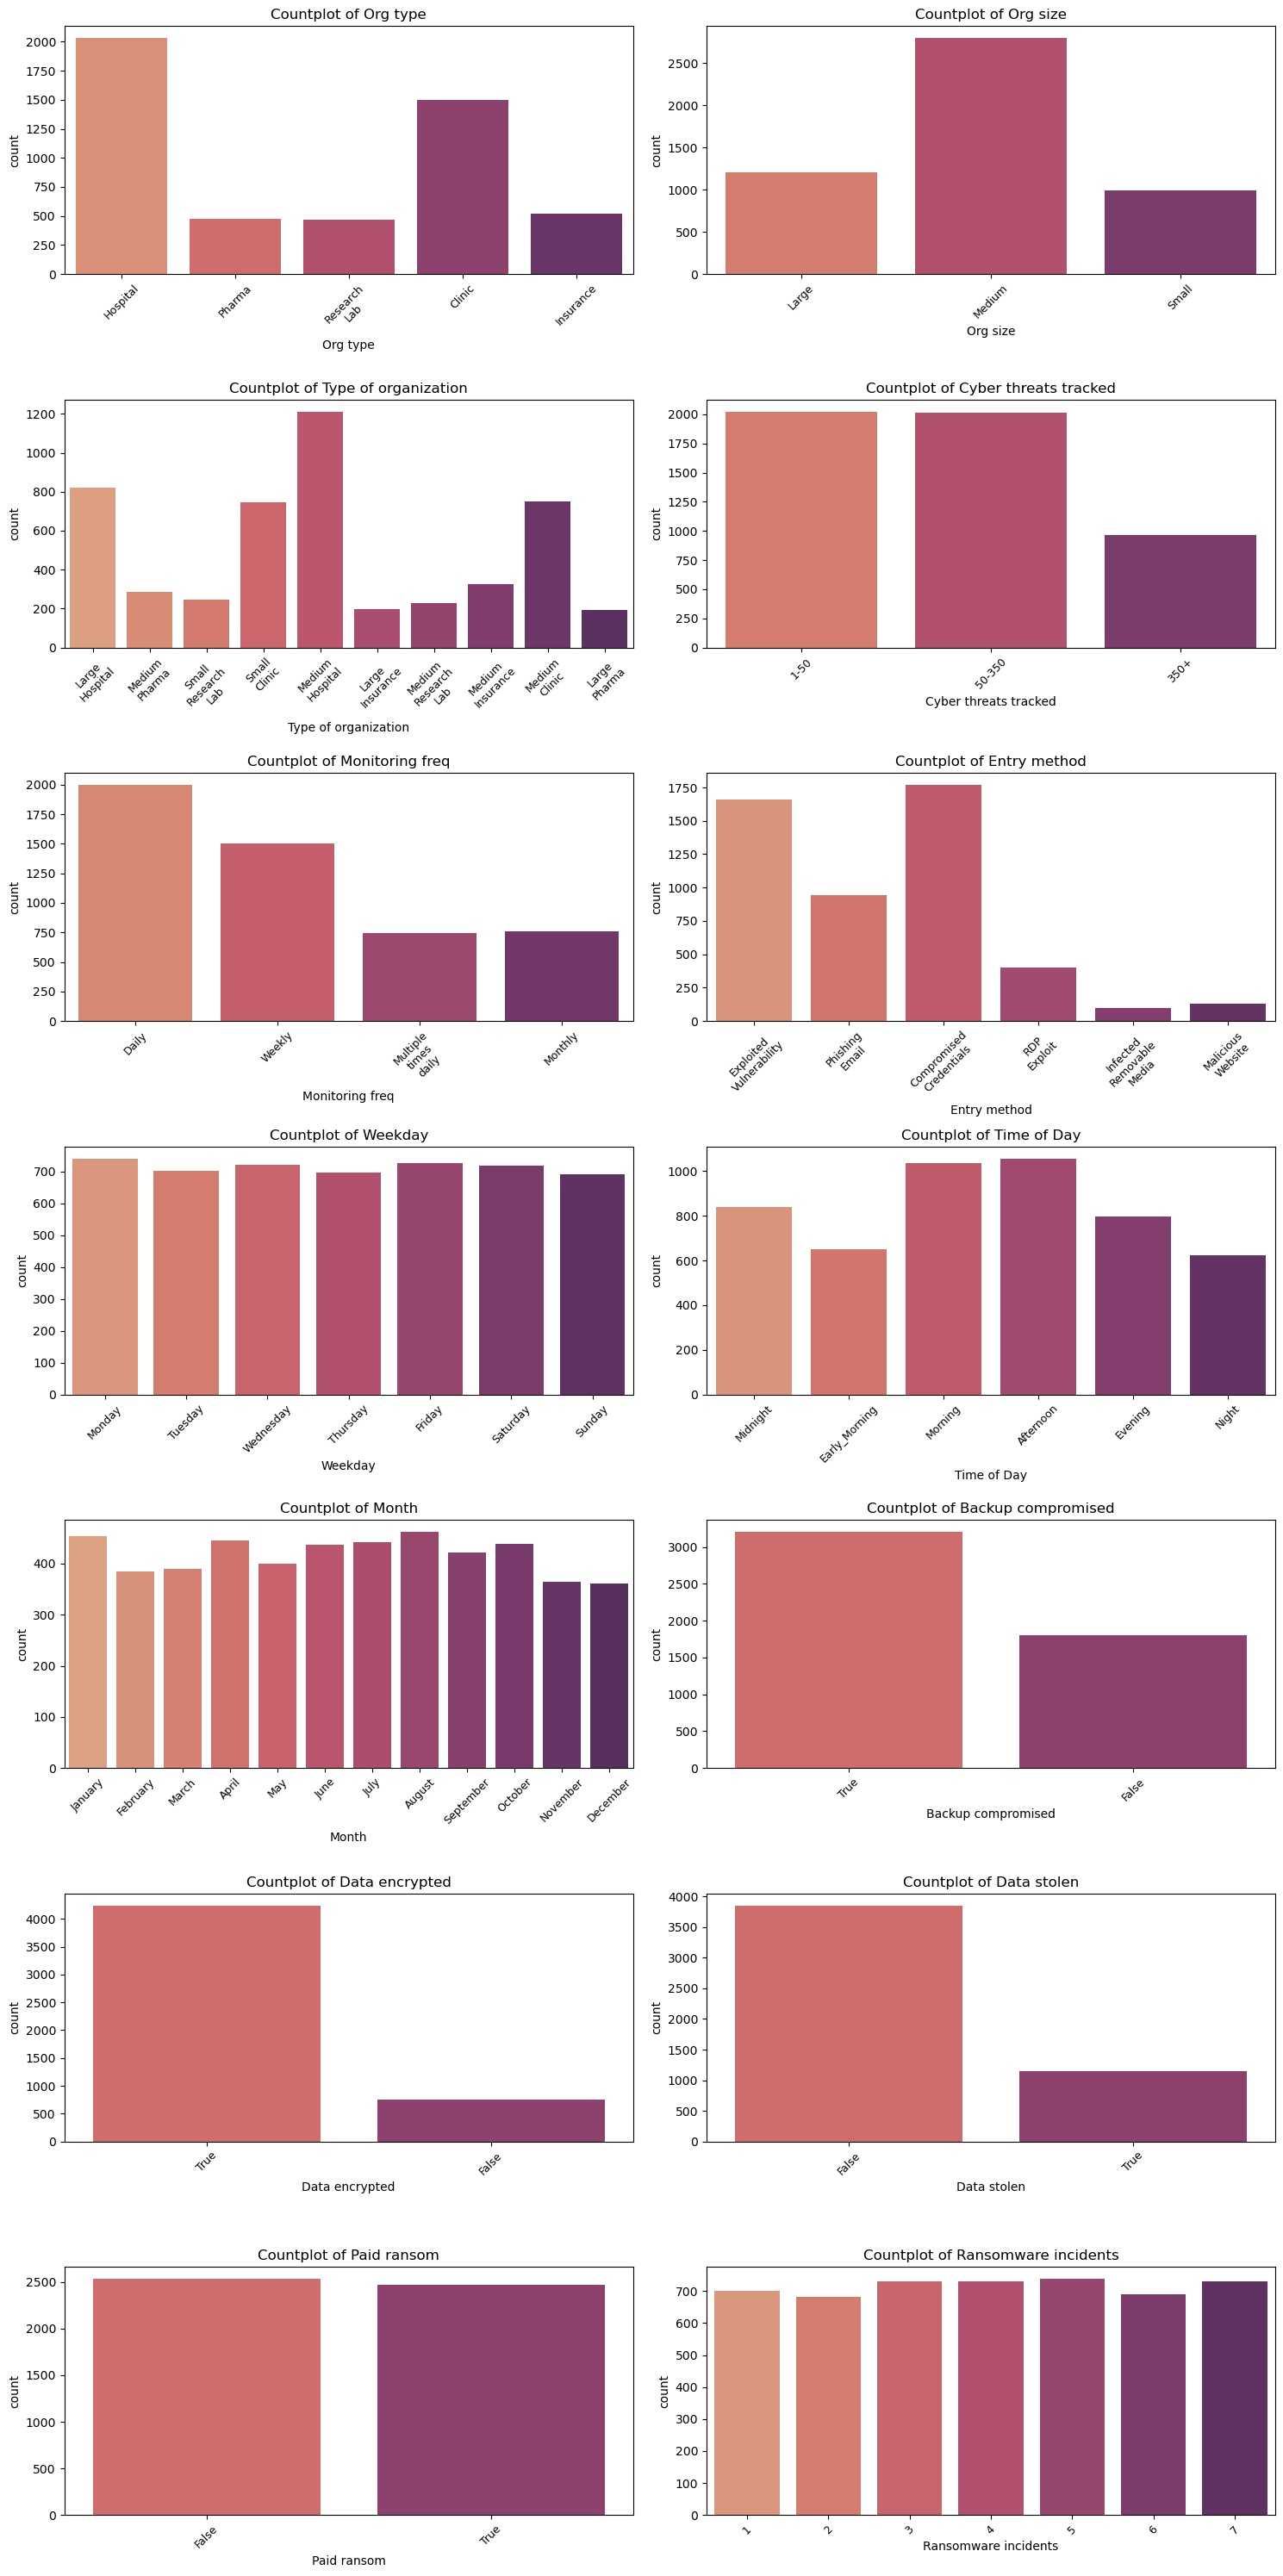

<Figure size 640x480 with 0 Axes>

In [29]:

# 1) A Grid of subplots for countplots for all categorical parameters
count_cols = ['Org type', 'Org size','Type of organization',
       'Cyber threats tracked', 'Monitoring freq', 'Entry method','Weekday',
       'Time of Day','Month','Backup compromised', 'Data encrypted', 'Data stolen', 
       'Paid ransom','Ransomware incidents',]

plt.figure(figsize=(15, 30))

for i, col in enumerate(count_cols):  
    plt.subplot(7, 2, i+1) 
    temp = df.copy() 
    temp[col] = temp[col].astype(str).str.replace(' ', '\n') 
    sns.countplot(data=temp, x=col, palette="flare",order=orders.get(col))
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45,fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig("my_plot.png", dpi=300, bbox_inches="tight")

### Inferences from plot 1:

Org Type:
Hospitals appear most frequently in the dataset, followed by Clinics. Pharma, Research Labs and Insurance have relatively fewer entries.

Org Size:
Medium-sized organizations dominate the sample. Small organizations come next, while large organizations are fewer.

Type of Organization (combined):
The combined labels show higher representation of medium and hospital-category combinations.

Cyber Threats Tracked:
Most organizations track between 1–50 or 50–350 threats. Very few track 350+ threats.

Monitoring Frequency:
Daily monitoring is the most common, followed by weekly monitoring. Monthly and multiple-times-daily monitoring are less common.

Entry Method:
Compromised credentials and exploited vulnerabilities are the most frequent attack vectors. Infected removable media and malicious websites occur less often.

Weekday / Time of Day / Month:
Incidents are fairly evenly spread across weekdays. Morning and afternoon show slightly higher counts than late night. Months show moderate variation but nothing exceptionally skewed.

Backup Compromised / Data Encrypted / Data Stolen:
Most cases show backups being compromised. Data is often encrypted, but data theft is less common. Paid ransom cases are roughly balanced between true and false.

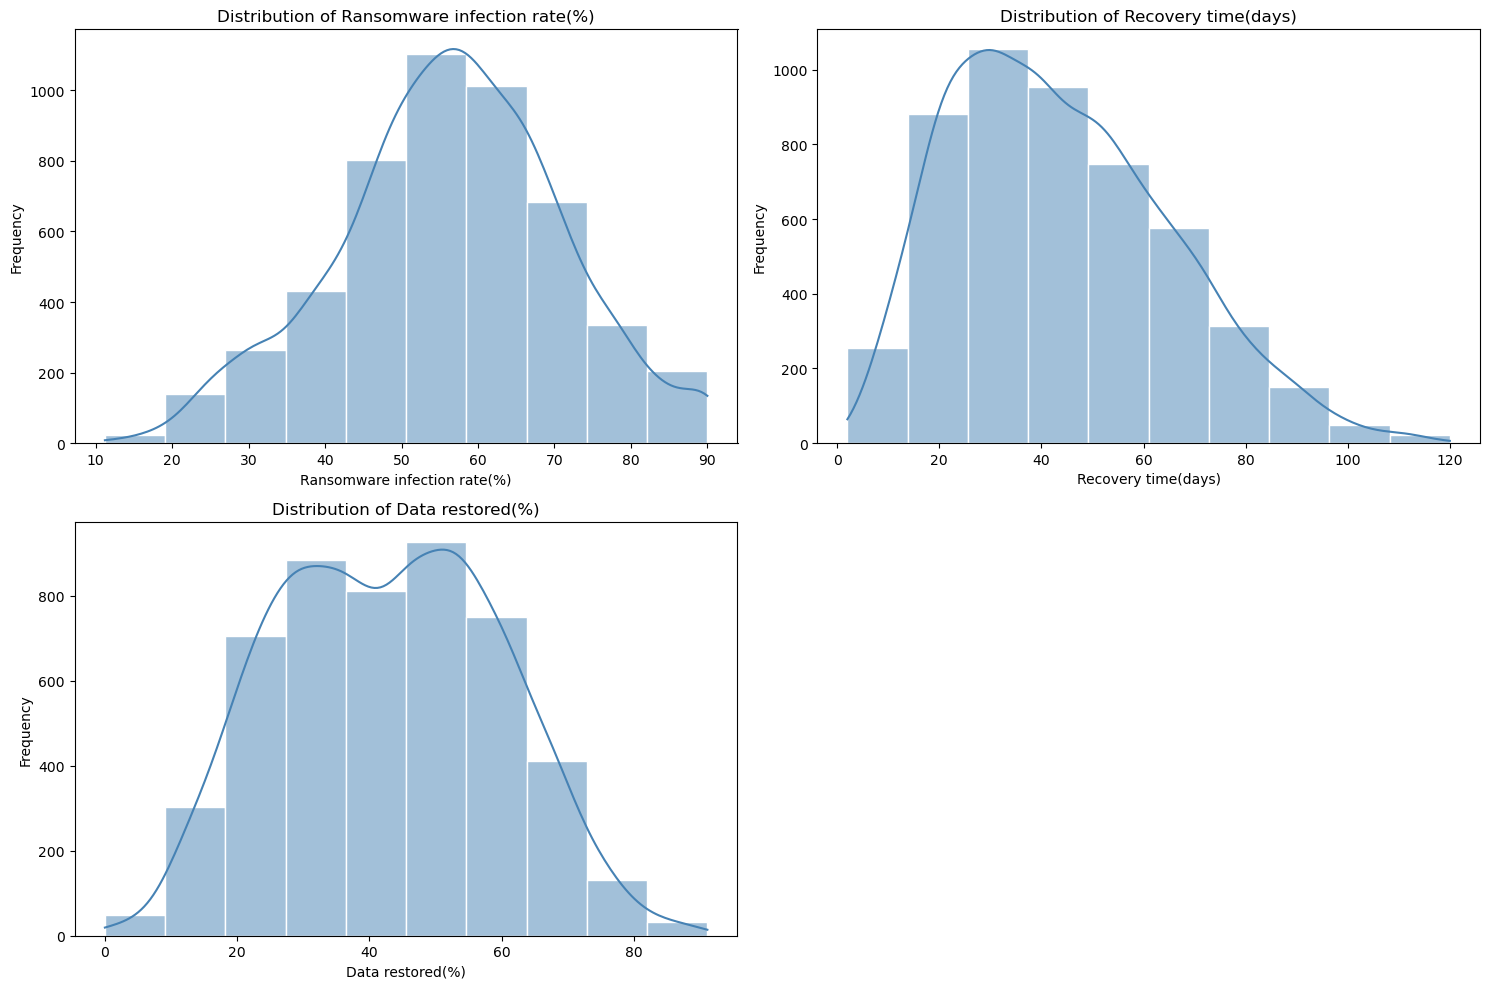

In [30]:
# 2) Grid with histograms for CN vars:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Data restored(%)',
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2, i)
    sns.histplot(df[col], bins=10, kde=True, color='steelblue',edgecolor='white')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
plt.tight_layout()
plt.show()

Inferences: 
Ransomware Infection Rate:
The distribution is roughly normal, centred around the 50–60% range.

Recovery Time:
Right-skewed distribution, meaning several organizations take significantly longer to recover, but most finish within 20–60 days.

Data Restored:
Mostly centred around 40–55%. A few cases show very low or very high restoration.

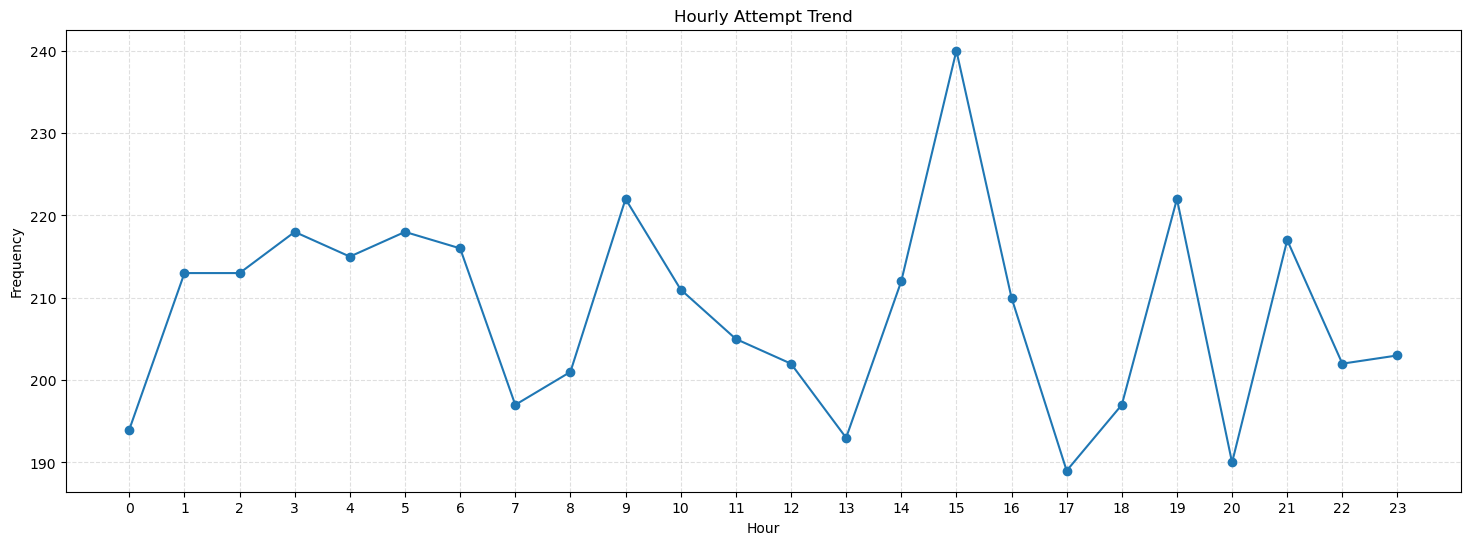

In [31]:
# 3) Line plot for feq distribution by hour
plt.figure(figsize=(18,6))

df['Hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.title('Hourly Attempt Trend')

plt.xticks(ticks=range(24), labels=range(24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

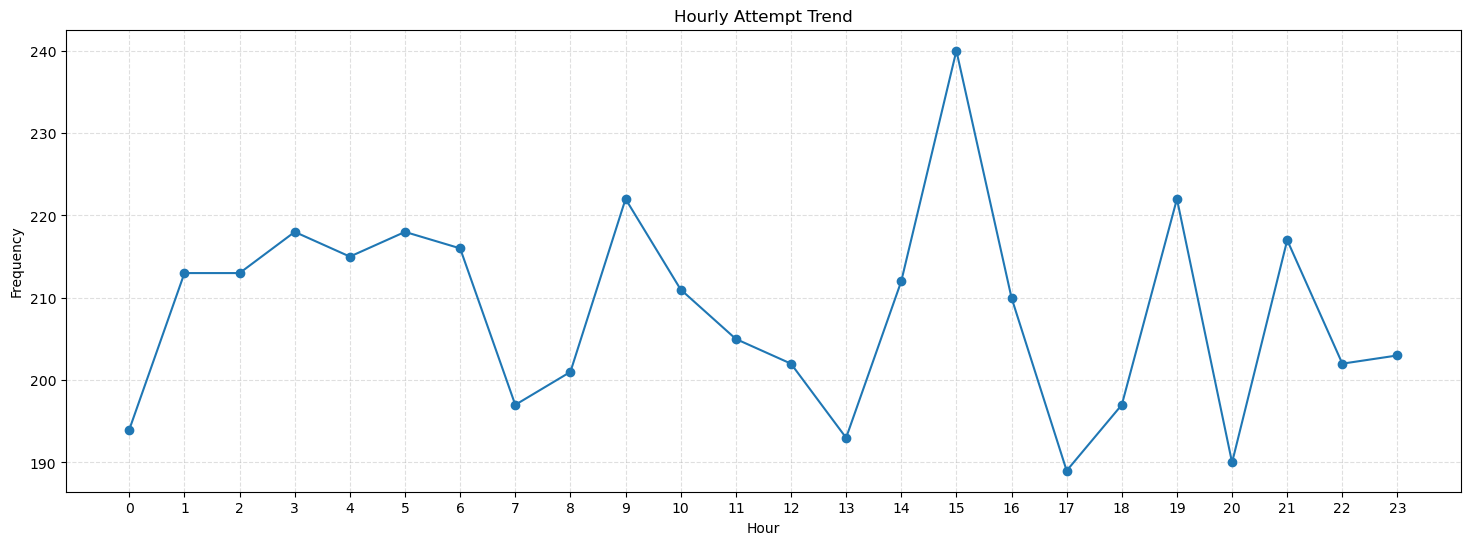

In [32]:
# 3) Line plot for feq distribution by hour
plt.figure(figsize=(18,6))

df['Hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.title('Hourly Attempt Trend')

plt.xticks(ticks=range(24), labels=range(24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Inferences: Frequency by Hour:
Attack attempts appear consistently through the day with mild fluctuations. There is no hour with extreme spikes, suggesting attackers operate uniformly rather than targeting specific hours.

Mean Infection Rate by Hour:
The infection rate also remains stable throughout the day with small hour-to-hour variations. There is no strong pattern indicating time-based vulnerability.

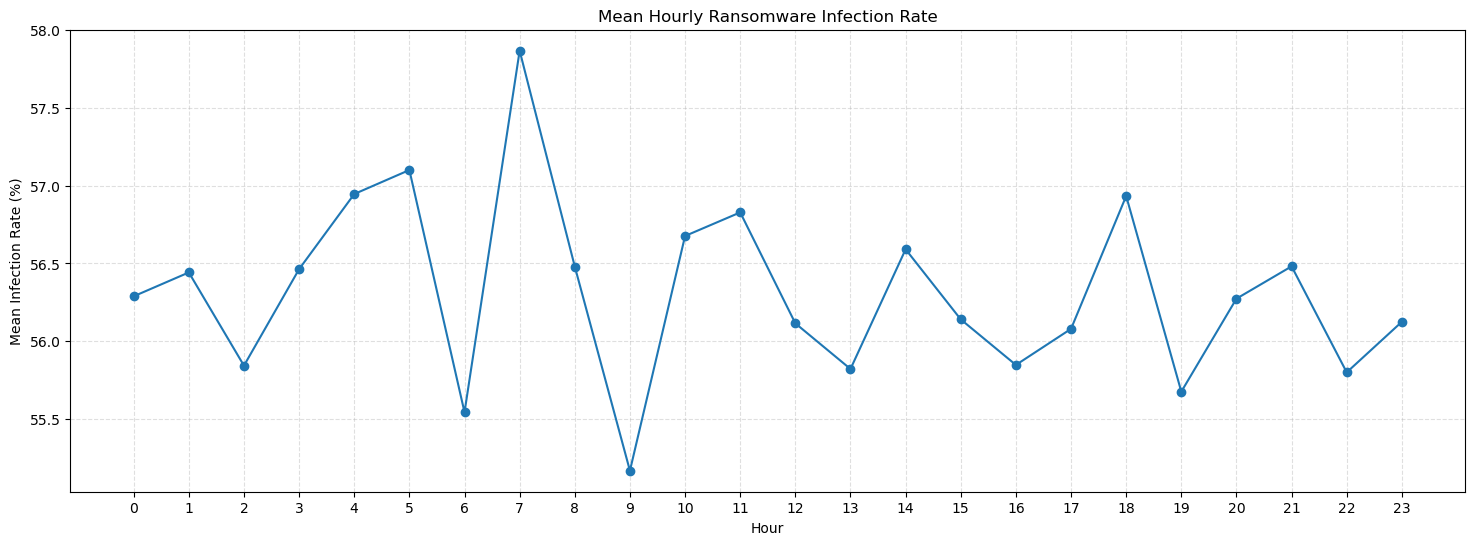

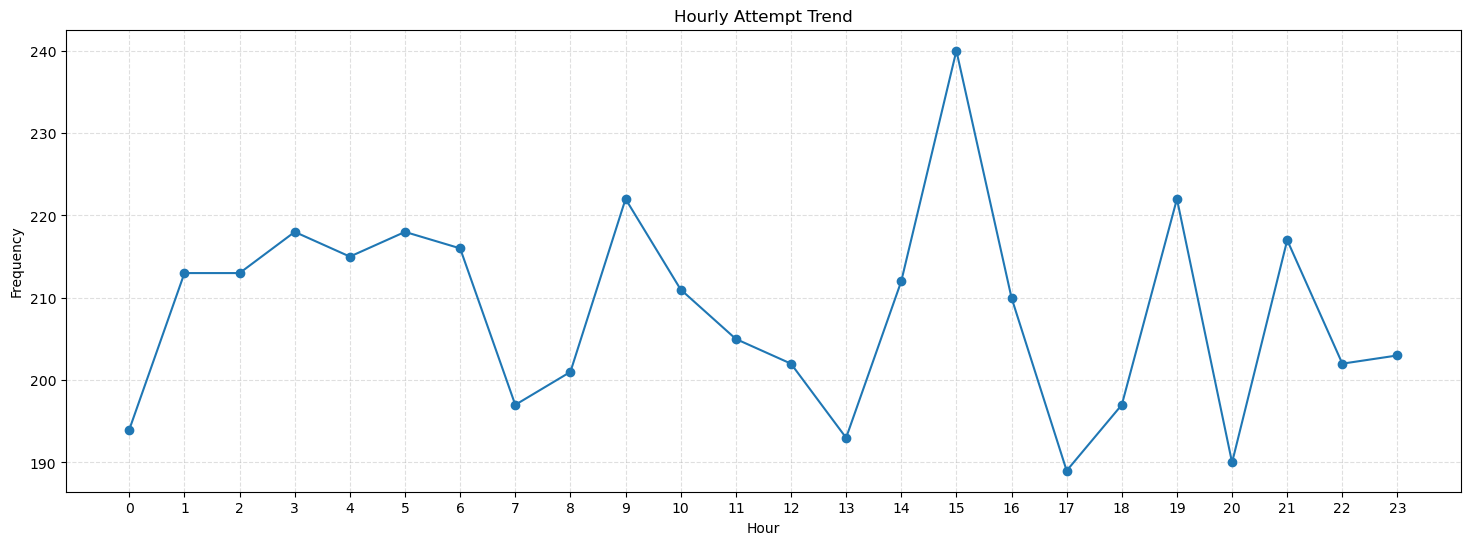

In [33]:
plt.figure(figsize=(18,6))

df.groupby('Hour')['Ransomware infection rate(%)'] \
  .mean().sort_index().plot(kind='line', marker='o')

plt.xlabel('Hour')
plt.ylabel('Mean Infection Rate (%)')
plt.title('Mean Hourly Ransomware Infection Rate')

plt.xticks(ticks=range(24), labels=range(24))
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

# 3) Line plot for feq distribution by hour
plt.figure(figsize=(18,6))

df['Hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.title('Hourly Attempt Trend')

plt.xticks(ticks=range(24), labels=range(24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [133]:
df.dtypes

Attack date                     datetime64[ns]
Org type                                object
Org size                                object
Facilities affected                      int64
Cyber threats tracked                   object
Monitoring freq                         object
Backup compromised                        bool
Ransomware infection rate(%)           float64
Data encrypted                            bool
Data stolen                               bool
Recovery time(days)                      int64
Entry method                            object
Paid ransom                               bool
Data restored(%)                       float64
Ransomware incidents                     int64
Date                                    object
Hour                                     int32
Weekday                                 object
Month                                   object
Time of Day                             object
Type of organization                    object
dtype: object

In [138]:
df.dtypes
df['Day'].value_counts().sort_index()

Day
1     164
2     173
3     177
4     157
5     151
6     159
7     174
8     162
9     162
10    150
11    162
12    166
13    172
14    180
15    166
16    185
17    173
18    164
19    164
20    166
21    156
22    168
23    150
24    168
25    153
26    156
27    156
28    167
29    158
30    152
31     89
Name: count, dtype: int64

In [34]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Data restored(%)',
    'Facilities affected']
def cat_num_heatmap(df, cat_col, num_cols, cmap='flare'):
    
#Creates a heatmap of mean numeric values grouped by a categorical column.
    
# Mean pivot
    mean_df = df.pivot_table(
        values=num_cols,
        index=cat_col,
        aggfunc='mean'
    )
    
# Std pivot
    std_df = df.pivot_table(
        values=num_cols,
        index=cat_col,
        aggfunc='std'
    )
    
# Annotation text: mean ± std
    annot_df = mean_df.round(1).astype(str) + " ± " + std_df.round(1).astype(str)
    
# Plot heatmap
    plt.figure(figsize=(12,6))
    sns.heatmap(mean_df, annot=annot_df, fmt='', cmap=cmap)
    plt.title(f"Mean ± Std Dev for Numeric Metrics by {cat_col}", fontsize=14)
    plt.ylabel(cat_col)
    plt.show()

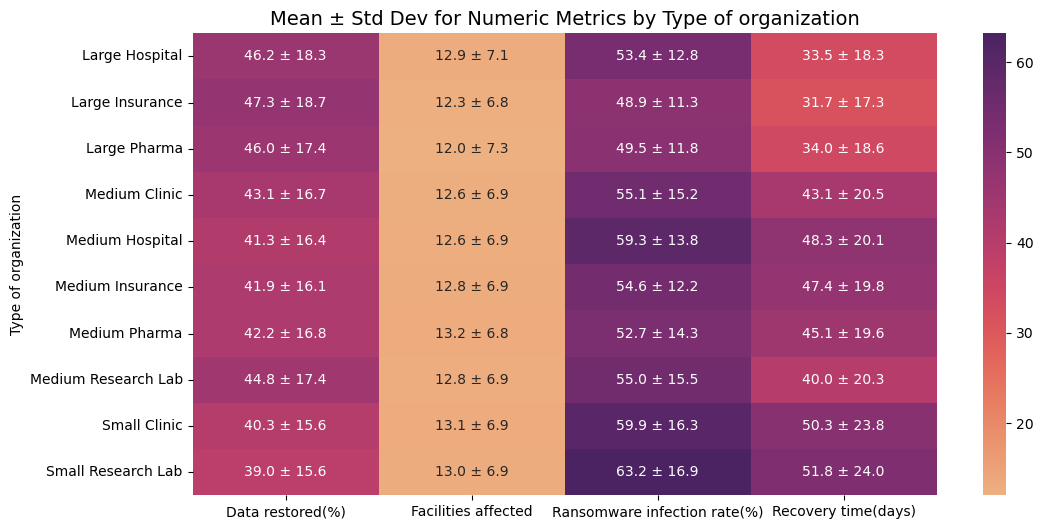

In [35]:
cat_num_heatmap(df,'Type of organization', num_cols)

In [202]:
df.columns

Index(['Attack date', 'Org type', 'Org size', 'Facilities affected',
       'Cyber threats tracked', 'Monitoring freq', 'Backup compromised',
       'Ransomware infection rate(%)', 'Data encrypted', 'Data stolen',
       'Recovery time(days)', 'Entry method', 'Paid ransom',
       'Data restored(%)', 'Ransomware incidents', 'Date', 'Hour', 'Weekday',
       'Month', 'Time of Day', 'Type of organization', 'Day', 'Week num'],
      dtype='object')

In [212]:
df.dtypes

Attack date                     datetime64[ns]
Org type                                object
Org size                                object
Facilities affected                      int64
Cyber threats tracked                   object
Monitoring freq                         object
Backup compromised                        bool
Ransomware infection rate(%)           float64
Data encrypted                            bool
Data stolen                               bool
Recovery time(days)                      int64
Entry method                            object
Paid ransom                               bool
Data restored(%)                       float64
Ransomware incidents                     int64
Date                            datetime64[ns]
Hour                                     int32
Weekday                                 object
Month                                   object
Time of Day                             object
Type of organization                    object
Day          

In [36]:
df.groupby('Month')['Ransomware infection rate(%)'].agg(['mean', 'std'])
df.groupby('Day')['Ransomware infection rate(%)'].agg(['mean','std'])

,mean,std
Day,,
1,56.085549,14.782299
2,56.139075,14.228666
3,55.955593,14.167012
4,56.052102,14.556284
5,56.693642,15.625697
6,56.182201,15.282992
7,56.009195,13.689020
8,55.661049,14.841763
9,56.230062,14.386334


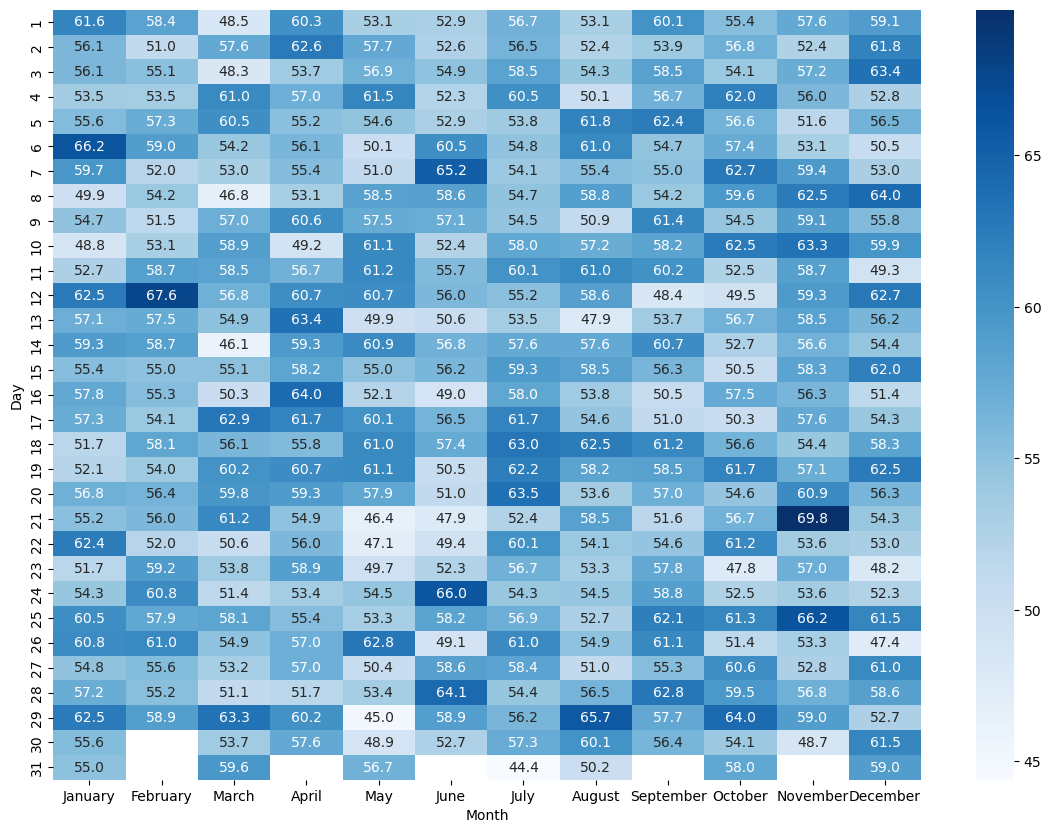

In [37]:
heatmap_data = df.pivot_table(
    values='Ransomware infection rate(%)',
    index=df['Day'],
    columns=df['Month'],
    aggfunc='mean'
)[month_order]  

plt.figure(figsize=(14,10))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='Blues')
plt.show()

Day-wise Monthly Heatmap:
Daily variations are random. No repeating pattern or month-specific behaviour is evident.

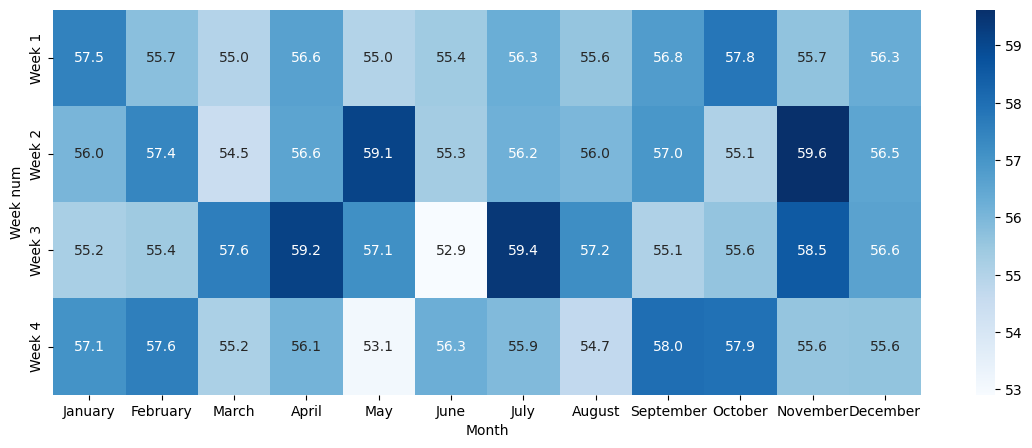

In [38]:
heatmap_data = df.pivot_table(
    values='Ransomware infection rate(%)',
    index=df['Week num'],
    columns=df['Month'],
    aggfunc='mean'
)[month_order]  

plt.figure(figsize=(14,5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='Blues')
plt.show()

Inferemces: Month × Week Number:
Week 2 and week 3 show scattered higher values in some months (e.g., April, November), but overall, patterns remain mild and inconsistent.

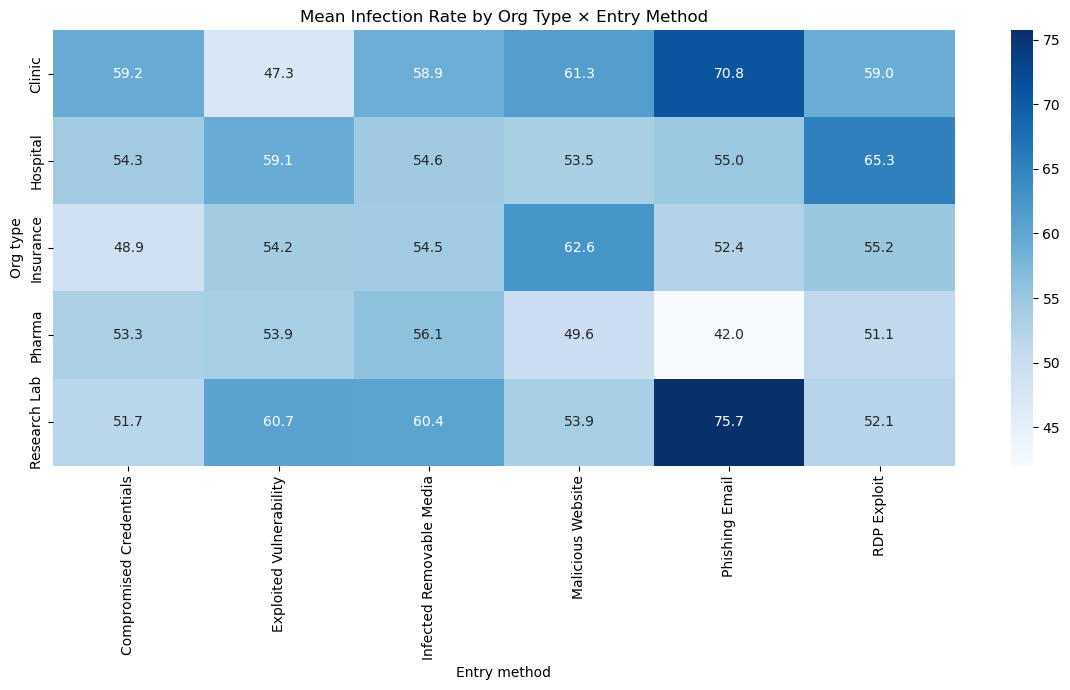

In [39]:
# 1. Infection Rate
pivot_infect = df.pivot_table(
    index='Org type',
    columns='Entry method',
    values='Ransomware infection rate(%)',
    aggfunc='mean'
)

plt.figure(figsize=(12,7))
plt.title("Mean Infection Rate by Org Type × Entry Method")
sns.heatmap(pivot_infect, annot=True, fmt='.1f', cmap='Blues')

plt.tight_layout()
plt.show()

Inferences: 1. Phishing hits some sectors much harder
Research Labs show the highest infection rates for phishing (~ 75%).
Clinics also get hit very hard (~ 71%).
Hospitals are moderate (~ 55%).
Pharma is lowest (~ 42%).

Phishing disproportionately affects Research Labs and Clinics.

2. Different sectors are vulnerable to different attack vectors
Research Labs: highest in phishing + removable media.
Insurance: highest in malicious websites.
Pharma: lowest in phishing but moderate elsewhere.

3. Hospitals are strongly affected by RDP exploit
RDP exploit infection rate is ~65% for hospitals.

4. Clinics are consistently high across almost all entry methods
Clinics have elevated infection rates for:
Compromised credentials
Exploited vulnerabilities
Malicious websites
Phishing

 Clinics appear to have weaker overall cybersecurity posture.

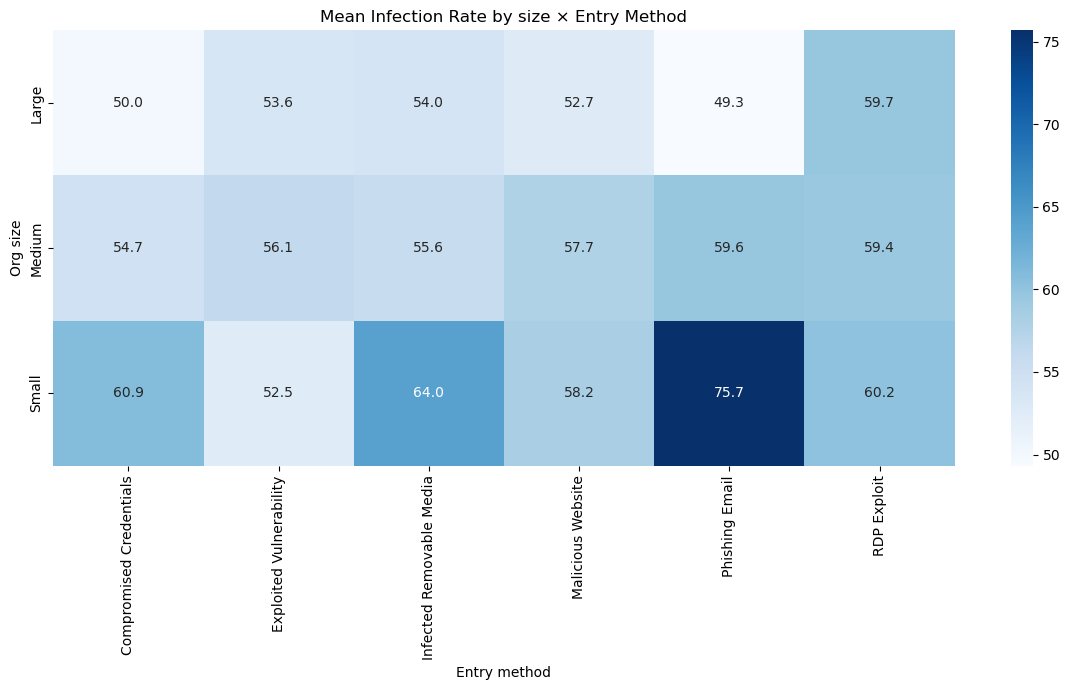

In [40]:
pivot_infect = df.pivot_table(
    index='Org size',
    columns='Entry method',
    values='Ransomware infection rate(%)',
    aggfunc='mean'
)

plt.figure(figsize=(12,7))
sns.heatmap(pivot_infect, annot=True, fmt='.1f', cmap='Blues')
plt.title("Mean Infection Rate by size × Entry Method")
plt.tight_layout()
plt.show()

Small organizations are the most vulnerable across nearly all entry methods, especially phishing and removable media. Medium organizations face moderate but consistent risk, while large organizations show significantly lower infection rates, indicating stronger cyber defenses. RDP exploits remain a high-risk vector for all sizes.

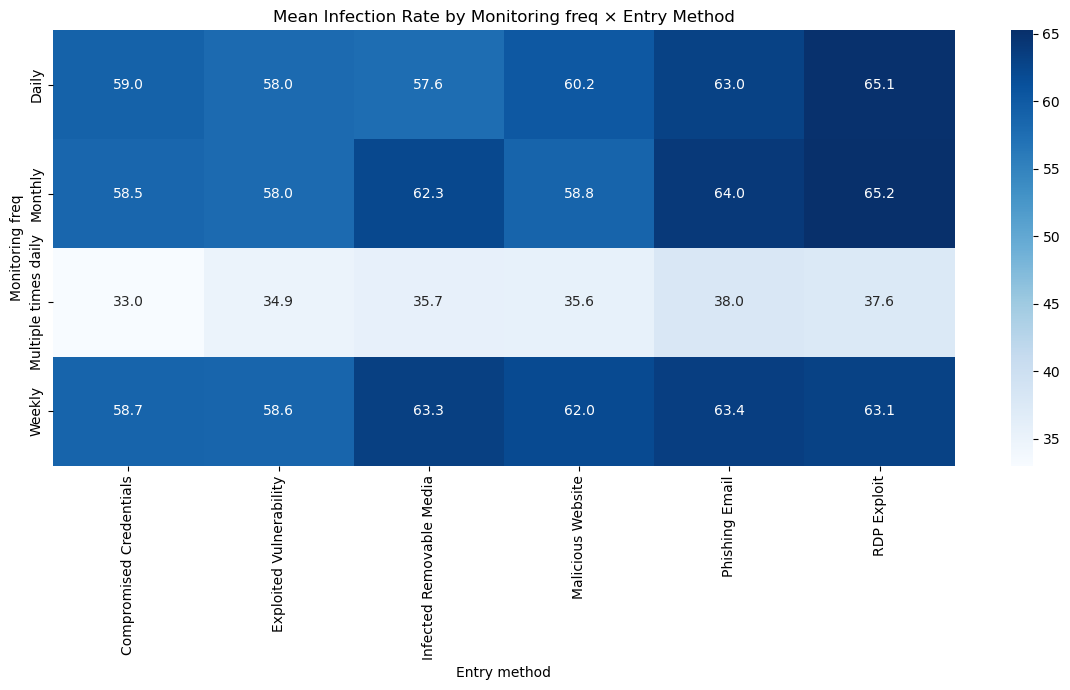

In [41]:
pivot_infect = df.pivot_table(
    index='Monitoring freq',
    columns='Entry method',
    values='Ransomware infection rate(%)',
    aggfunc='mean'
)

plt.figure(figsize=(12,7))
sns.heatmap(pivot_infect, annot=True, fmt='.1f', cmap='Blues')
plt.title("Mean Infection Rate by Monitoring freq × Entry Method")

plt.tight_layout()
plt.show()

Inferences: Monthly and weekly monitoring show higher infection rates (especially phishing and RDP).

Multiple-times-daily monitoring shows the lowest infection rates across all entry methods.

Daily monitoring performs moderately well, better than monthly but worse than multiple-times-daily.

Conclusion: More frequent monitoring strongly correlates with lower infection rates.

In [221]:
df.columns

Index(['Attack date', 'Org type', 'Org size', 'Facilities affected',
       'Cyber threats tracked', 'Monitoring freq', 'Backup compromised',
       'Ransomware infection rate(%)', 'Data encrypted', 'Data stolen',
       'Recovery time(days)', 'Entry method', 'Paid ransom',
       'Data restored(%)', 'Ransomware incidents', 'Date', 'Hour', 'Weekday',
       'Month', 'Time of Day', 'Type of organization', 'Day', 'Week num'],
      dtype='object')

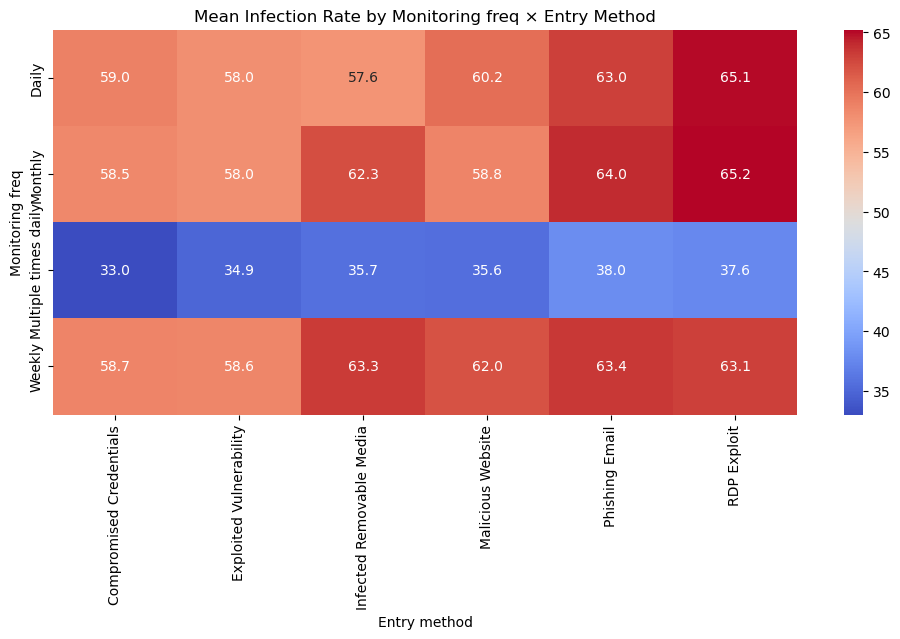

In [42]:
pivot = df.pivot_table(
    index='Monitoring freq',
    columns='Entry method',
    values='Ransomware infection rate(%)',
    aggfunc='mean'
)

plt.figure(figsize=(12,5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Mean Infection Rate by Monitoring freq × Entry Method")
plt.show()

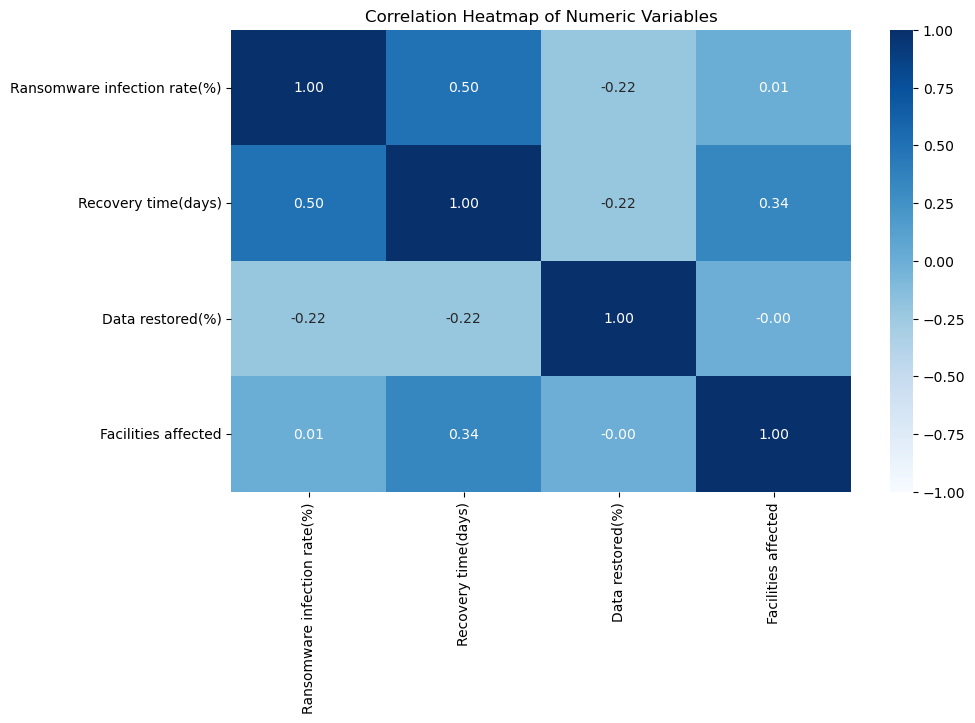

In [43]:
# multivariate analysis
corr = df[num_cols].corr() # correlation factors

plt.figure(figsize=(10, 6))
sns.heatmap(corr,  vmin=-1, vmax=1, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

Inferences: Correlation Heatmap

Infection rate moderately correlates with recovery time (0.50).

Data restored has weak negative correlation with both infection rate and recovery time.

Facilities affected has weak correlation to all metrics.

Conclusion: There are no strong linear correlations except infection rate vs recovery time.

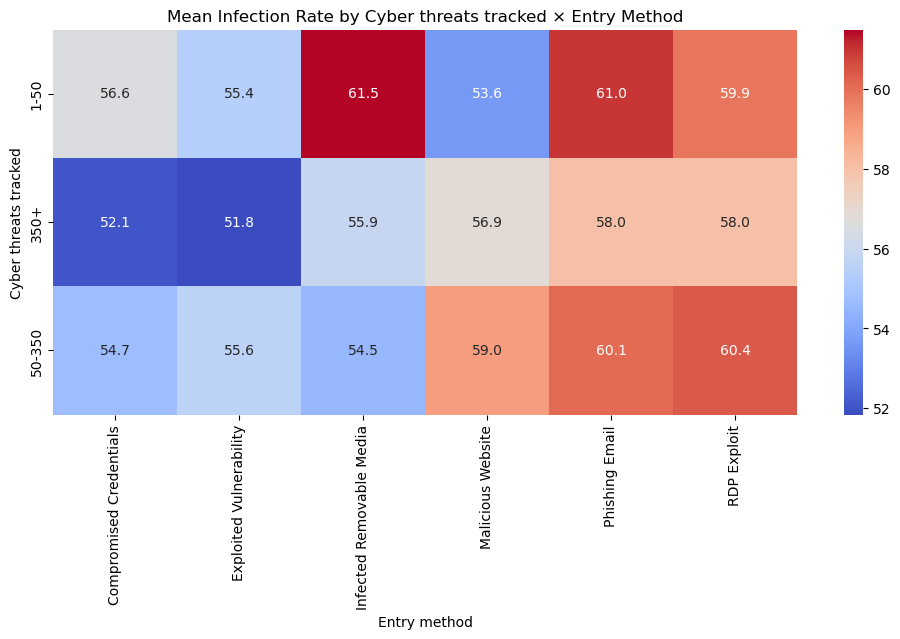

In [44]:
pivot = df.pivot_table(
    index='Cyber threats tracked',
    columns='Entry method',
    values='Ransomware infection rate(%)',
    aggfunc='mean'
)

plt.figure(figsize=(12,5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Mean Infection Rate by Cyber threats tracked × Entry Method")
plt.show()

Inferences: Organizations tracking only 1–50 threats show slightly higher infection under removable media and malicious website.

Organizations tracking 350+ threats show moderate but consistent infection rates across all methods.

Tracking more threats does not sharply reduce infection rate, but the 350+ group shows more stability.

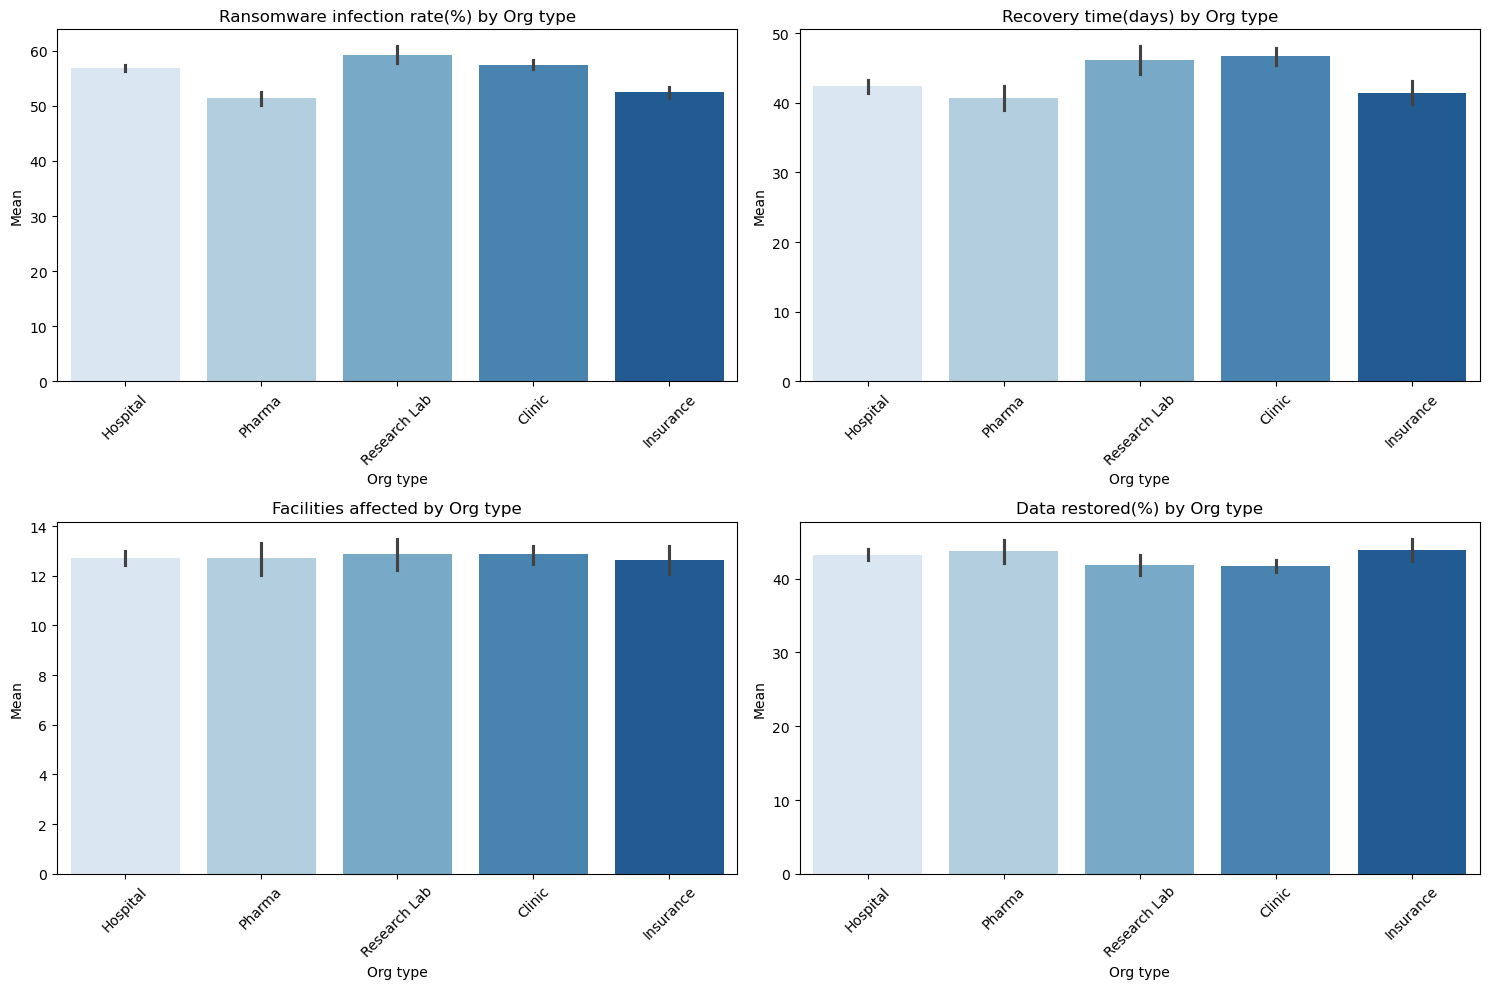

In [45]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Facilities affected',
    'Data restored(%)'
]

cat = 'Org type'

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=cat, y=col, estimator='mean', palette='Blues')
    plt.xticks(rotation=45)
    plt.title(f'{col} by {cat}')
    plt.ylabel("Mean")
    plt.xlabel(cat)

plt.tight_layout()
plt.show()

Inferences: Infection Rate:
Research Labs and Clinics have higher mean infection rates. Insurance and Pharma have lower rates.

Recovery Time:
Clinics and Research Labs take longer to recover compared to Pharma and Insurance.

Facilities Affected:
All org types show similar values with small variation.

Data Restored:
Insurance and Pharma restore slightly more data than Research Labs or Clinics.

Overall: Research Labs and Clinics face the worst impact in terms of infection and recovery time.

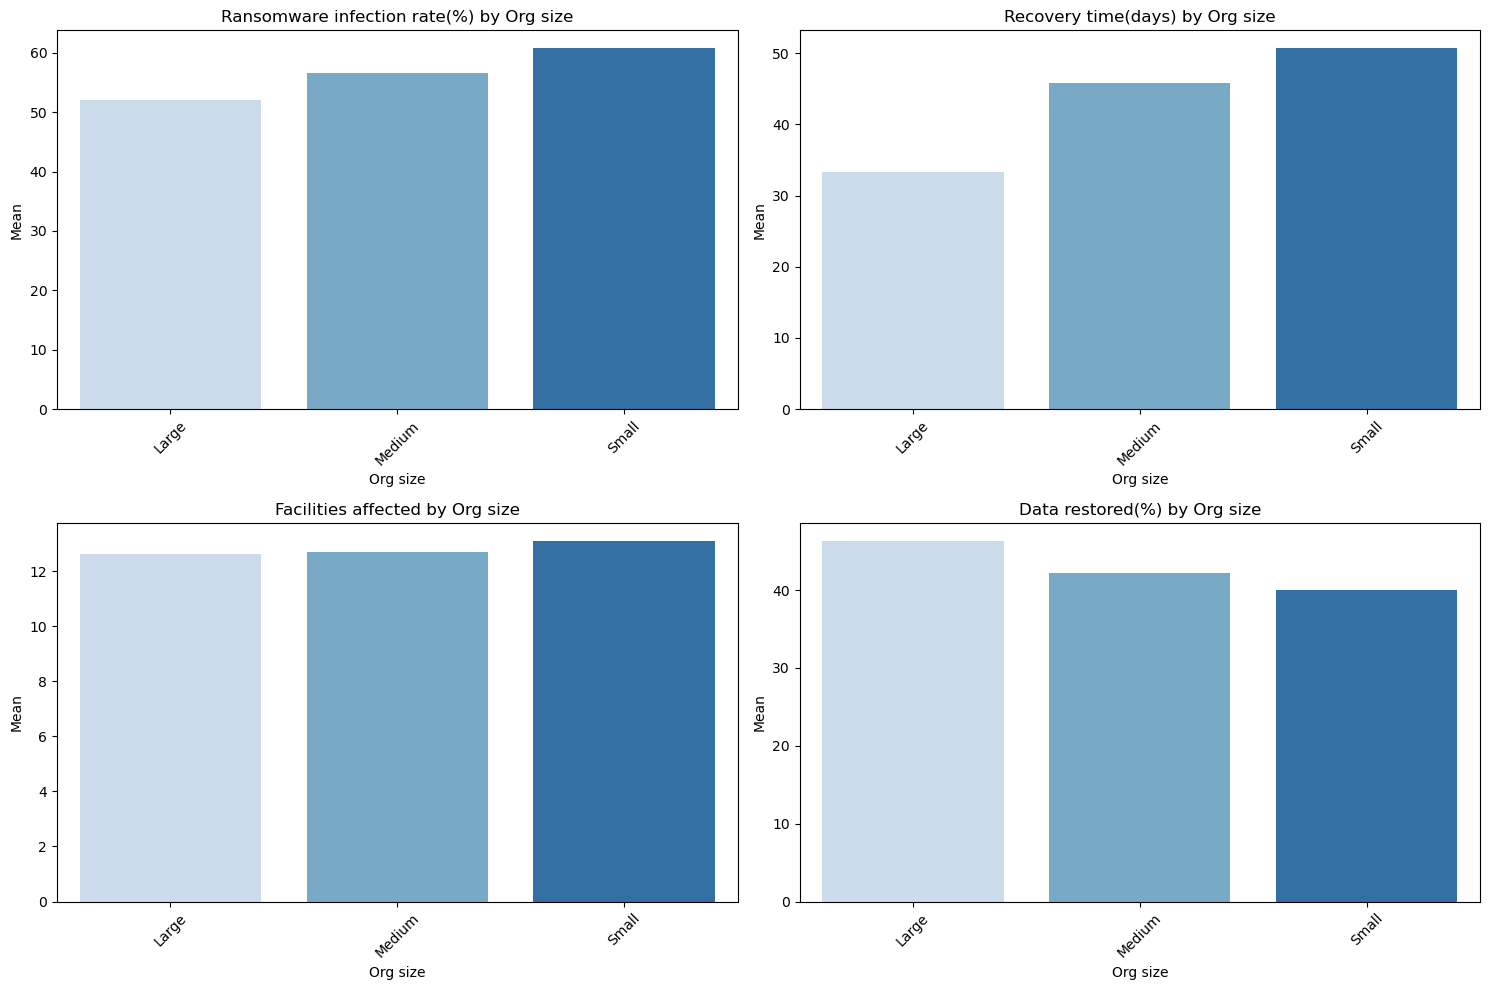

In [46]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Facilities affected',
    'Data restored(%)'
]

cat = 'Org size'

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=cat, y=col, estimator='mean', ci=None, palette='Blues')
    plt.xticks(rotation=45)
    plt.title(f'{col} by {cat}')
    plt.ylabel("Mean")
    plt.xlabel(cat)

plt.tight_layout()
plt.show()

Inferences: Infection Rate:
Small organizations experience the highest infection rate, followed by medium. Large organizations have the lowest.

Recovery Time:
Small organizations take the longest to recover. Large firms recover significantly faster.

Facilities Affected:
All org sizes show similar numbers of affected facilities.

Data Restored:
Large organizations restore the most data. Restoration steadily decreases as size decreases.

Conclusion: Smaller organizations suffer more damage and recover slower.

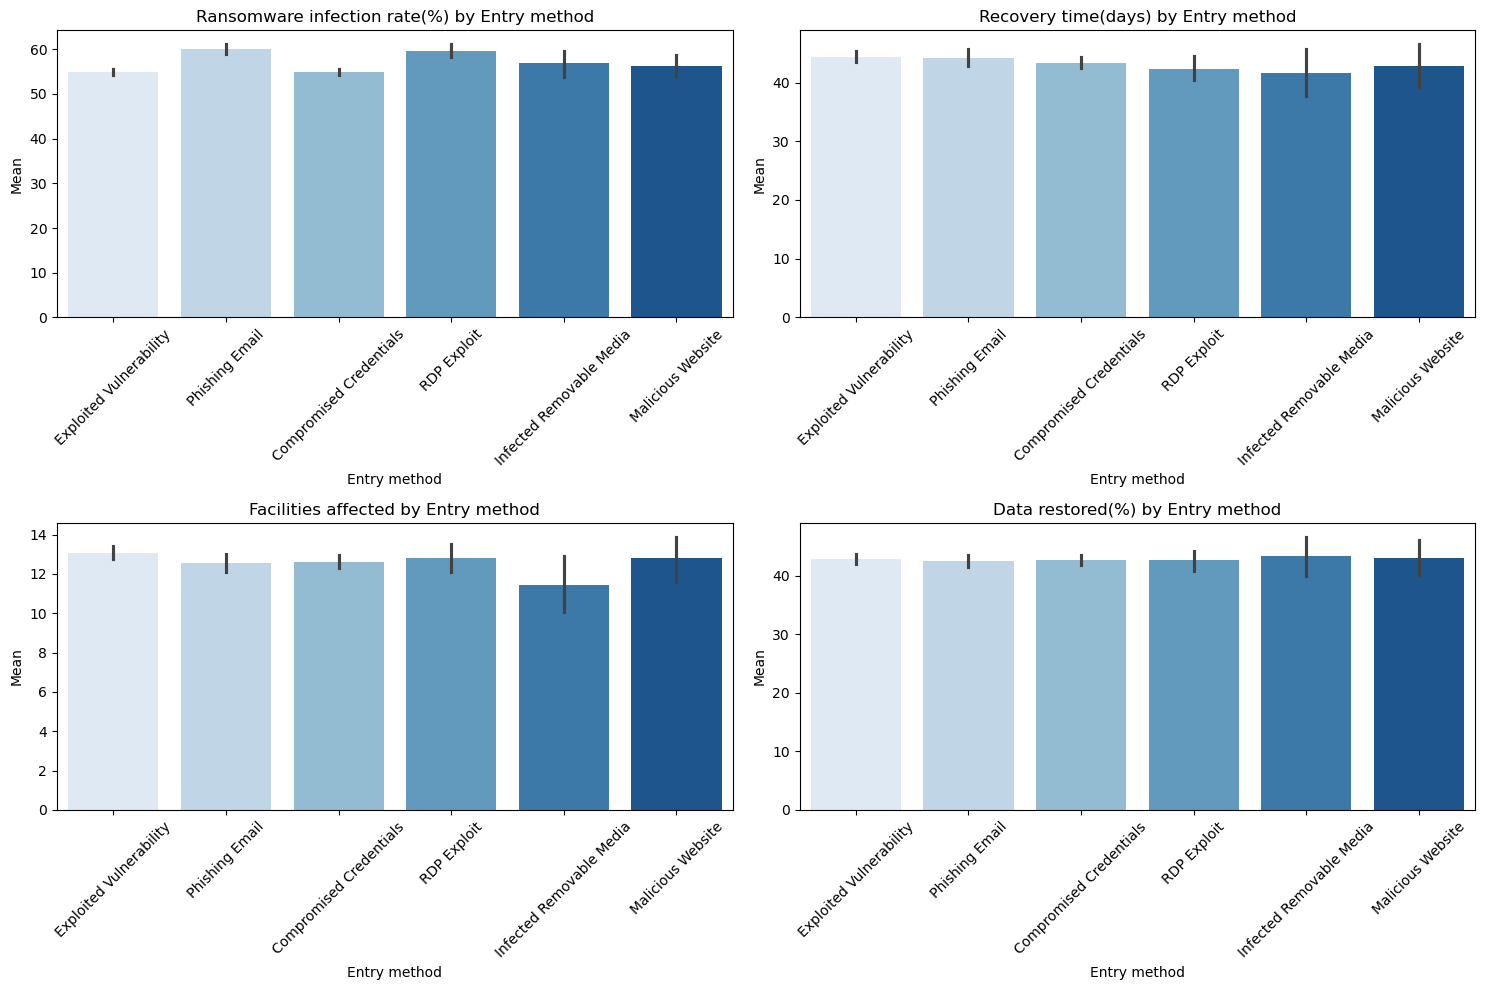

In [47]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Facilities affected',
    'Data restored(%)'
]

cat = 'Entry method'

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=cat, y=col, estimator='mean', palette='Blues')
    plt.xticks(rotation=45)
    plt.title(f'{col} by {cat}')
    plt.ylabel("Mean")
    plt.xlabel(cat)

plt.tight_layout()
plt.show()

Inferences: Infection Rate:
Phishing and RDP exploits cause the highest infection rates. Compromised credentials and malicious websites show intermediate values.

Recovery Time:
Recovery time is similar across methods, with only small differences.

Facilities Affected:
Most methods affect similar numbers of facilities.

Data Restored:
Data restoration remains relatively stable across methods.

Conclusion: Entry method strongly affects infection severity, but recovery and impact metrics remain similar.

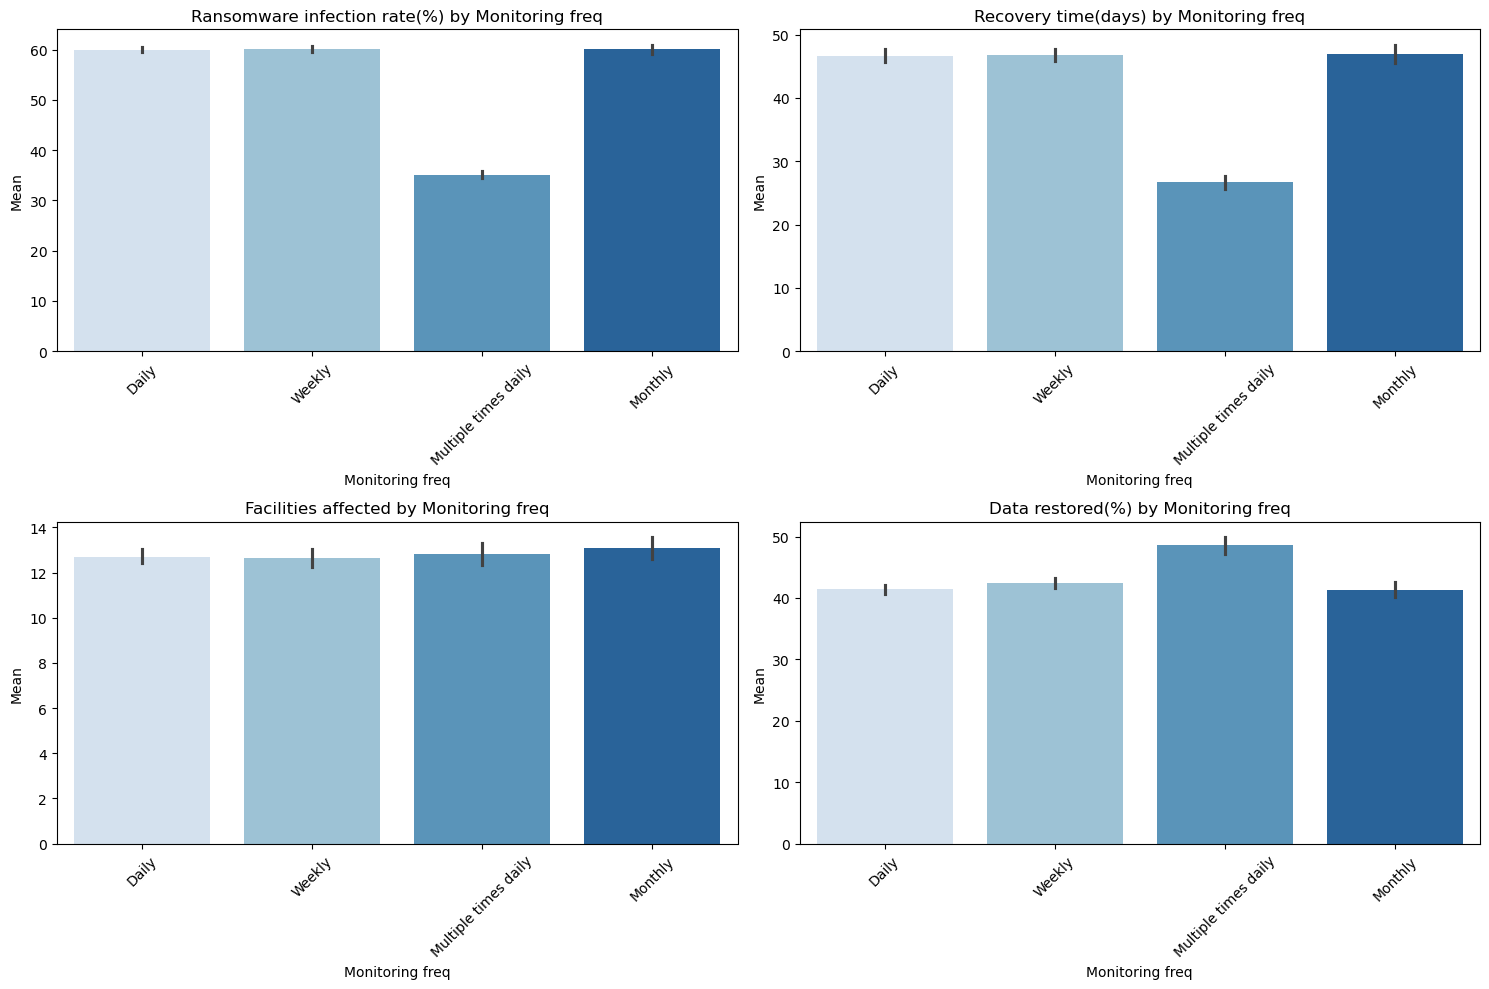

In [48]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Facilities affected',
    'Data restored(%)'
]

cat = 'Monitoring freq'

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=cat, y=col, estimator='mean', palette='Blues')
    plt.xticks(rotation=45)
    plt.title(f'{col} by {cat}')
    plt.ylabel("Mean")
    plt.xlabel(cat)

plt.tight_layout()
plt.show()

Inferences: Infection Rate:
Multiple-times-daily monitoring leads to dramatically lower infection rates. Monthly monitoring shows the highest.

Recovery Time:
Organizations monitoring multiple times daily recover much faster. Monthly monitoring recovers the slowest.

Facilities Affected:
Very similar across all frequencies.

Data Restored:
Multiple-times-daily monitoring also leads to higher data restored.

Conclusion: Monitoring frequency is a major factor for both prevention and faster recovery.

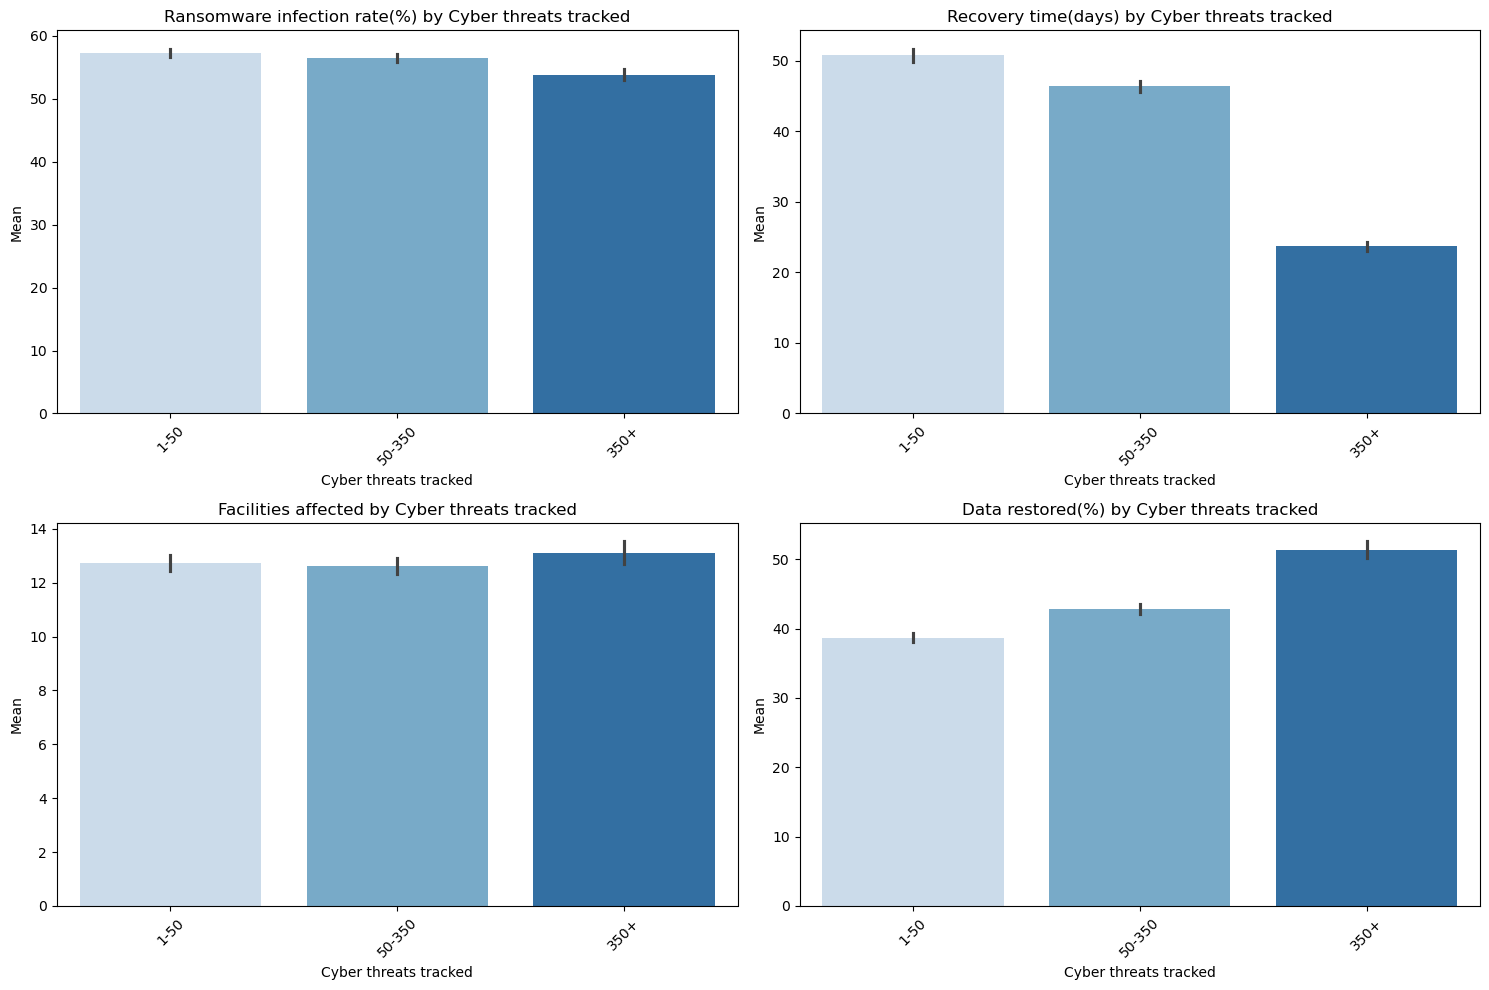

In [49]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Facilities affected',
    'Data restored(%)'
]

cat = 'Cyber threats tracked'

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=cat, y=col, estimator='mean', palette='Blues')
    plt.xticks(rotation=45)
    plt.title(f'{col} by {cat}')
    plt.ylabel("Mean")
    plt.xlabel(cat)

plt.tight_layout()
plt.show()

Inferences: Infection Rate:
Moderate decrease as the number of tracked threats increases. Tracking 350+ shows slightly better results.

Recovery Time:
Organizations tracking many threats (350+) recover faster.

Facilities Affected:
Slightly higher for the 350+ group, but not significantly different.

Data Restored:
Data restored increases as the number of tracked threats increases.

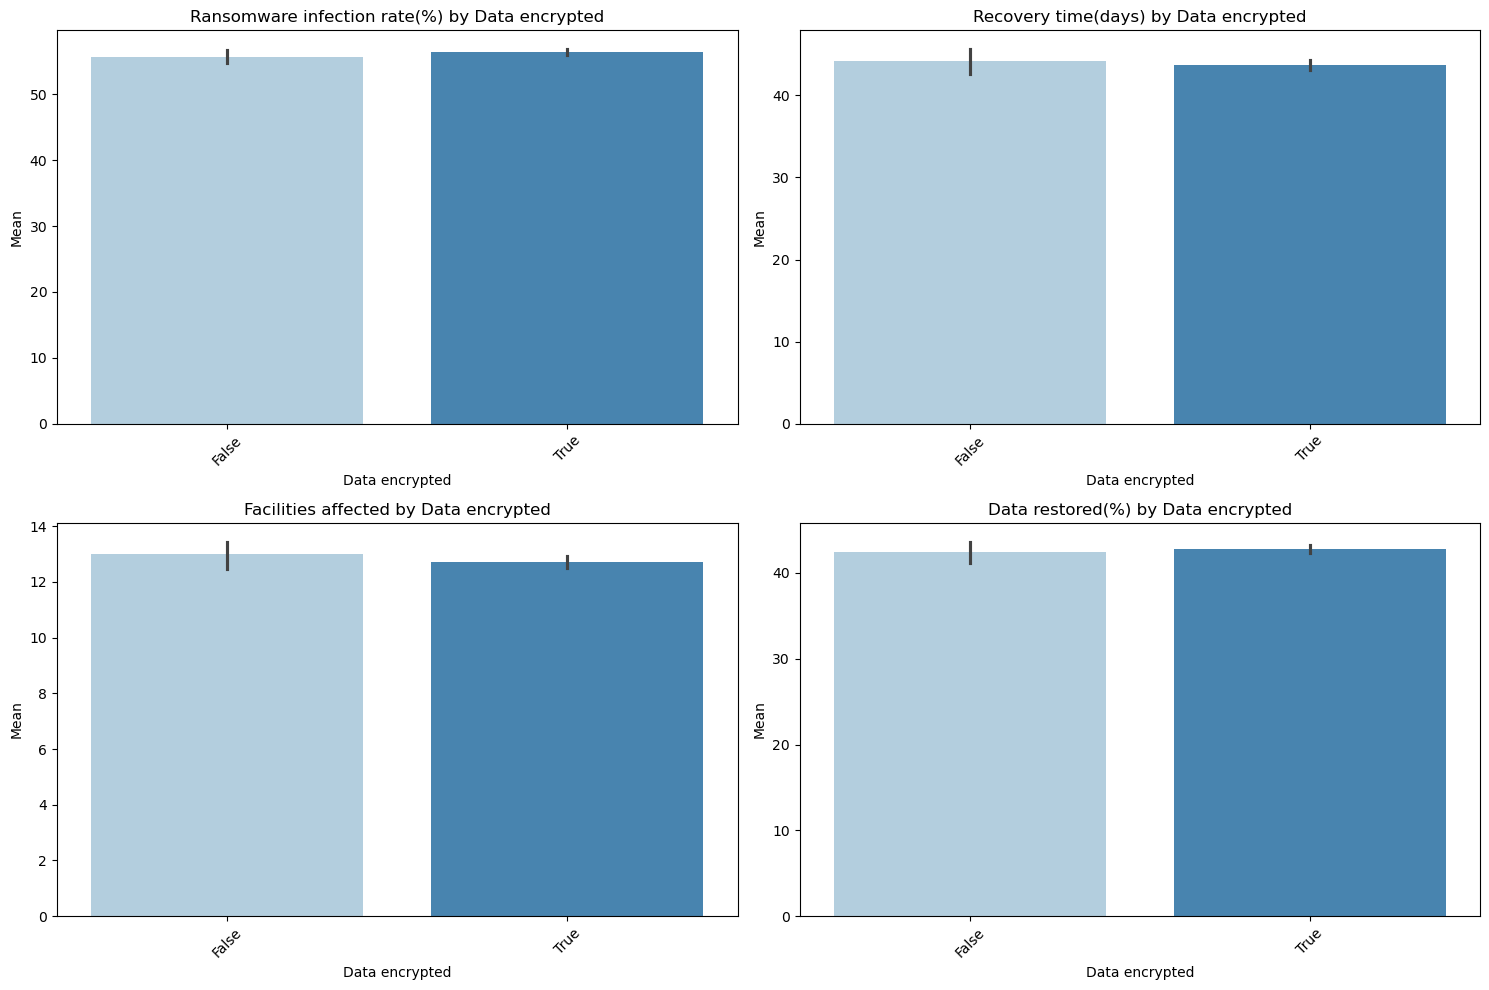

In [50]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Facilities affected',
    'Data restored(%)'
]

cat = 'Data encrypted'

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=cat, y=col, estimator='mean', palette='Blues')
    plt.xticks(rotation=45)
    plt.title(f'{col} by {cat}')
    plt.ylabel("Mean")
    plt.xlabel(cat)

plt.tight_layout()
plt.show()

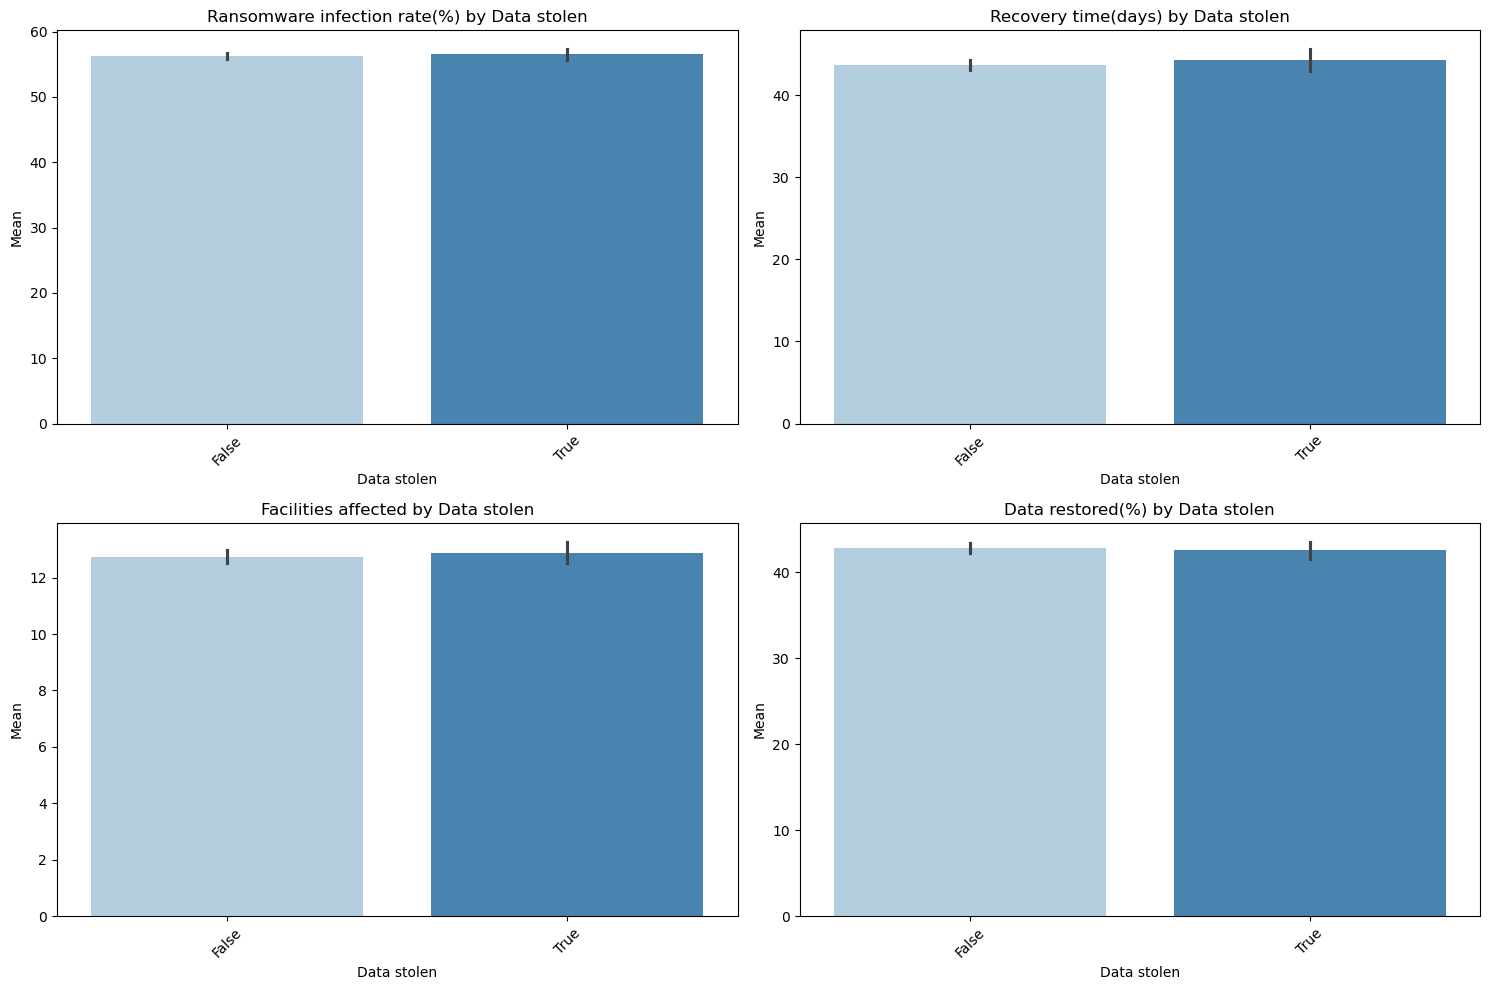

In [51]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Facilities affected',
    'Data restored(%)'
]

cat = 'Data stolen'

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=cat, y=col, estimator='mean', palette='Blues')
    plt.xticks(rotation=45)
    plt.title(f'{col} by {cat}')
    plt.ylabel("Mean")
    plt.xlabel(cat)

plt.tight_layout()
plt.show()

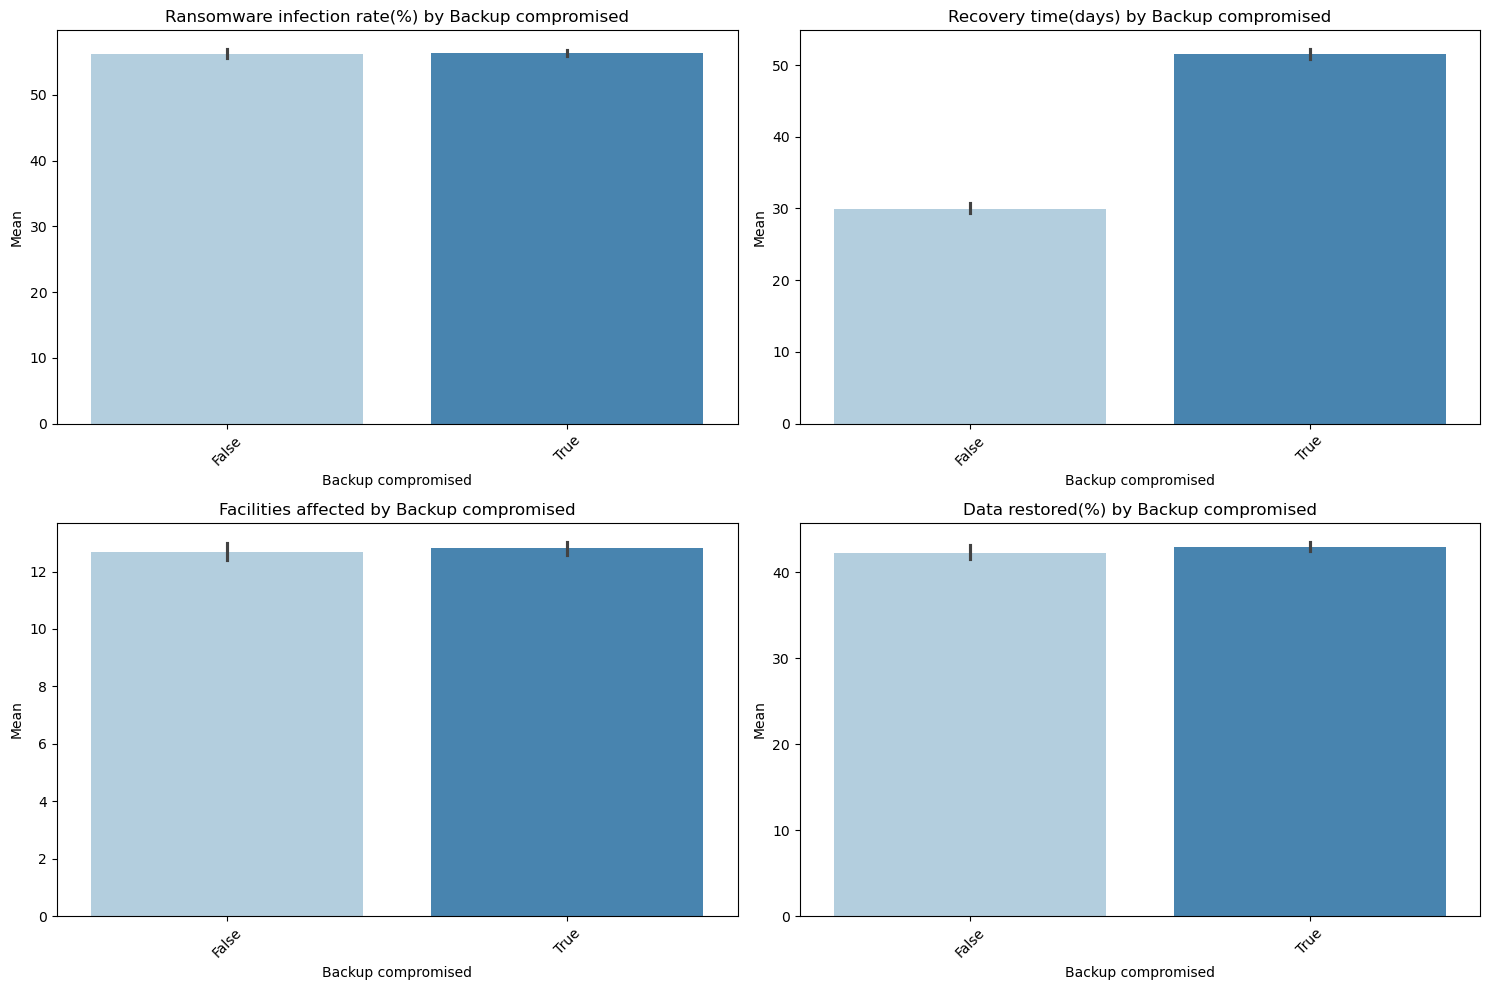

In [54]:
num_cols = [
    'Ransomware infection rate(%)',
    'Recovery time(days)',
    'Facilities affected',
    'Data restored(%)'
]

cat = 'Backup compromised'

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=cat, y=col, estimator='mean', palette='Blues')
    plt.xticks(rotation=45)
    plt.title(f'{col} by {cat}')
    plt.ylabel("Mean")
    plt.xlabel(cat)

plt.tight_layout()
plt.show()

Inferences: Barplots: Backup Compromised Analysis

Infection Rate:
Backups being compromised does not show major difference in infection rate.

Recovery Time:
Organizations with compromised backups take significantly longer to recover.

Data Restored:
Data restored drops slightly when backups are compromised.

Conclusion: Backup compromise does not affect infection probability but severely affects recovery.